In [31]:
import pandas as pd

recipe_classes_df = pd.read_csv("./input_stage2/recipe_classes.csv")
recipe_classes_df

,fdc_id,description,product,adj,verb,protein_g,fat_g,carb_g,energy_kcal,fiber_g,...,spicy,umami_rich,tangy_zesty,advanced_gourmet,one_pot_one_pan,generic,heat_level,cuisine_region,labels,n_labels
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","['layer buttermilk biscuits', 'dough']","['Golden', 'Artificial']",['refrigerated'],5.88,13.2400,41.1800,307.0,1.2,...,0,0,0,0,0,0,none,NaN,comfort_food|kid_friendly,2
1,167516,"Waffles, buttermilk, frozen, ready-to-heat",['waffles'],['ready'],['frozen'],6.58,9.2200,41.0500,273.0,2.2,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
2,167517,"Waffle, buttermilk, frozen, ready-to-heat, toa...",['waffle'],['ready'],"['frozen', 'toasted']",7.42,9.4900,48.3900,309.0,2.6,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
3,167518,"Waffle, buttermilk, frozen, ready-to-heat, mic...",['waffle'],['ready'],"['frozen', 'microwaved']",6.92,9.4000,44.1600,289.0,2.4,...,0,0,1,0,0,0,none,NaN,comfort_food|kid_friendly|tangy_zesty,3
4,167519,"Waffle, plain, frozen, ready-to-heat, microwave",['waffle'],"['plain', 'ready']",['frozen'],6.71,9.9100,45.4100,298.0,2.4,...,0,0,0,0,0,0,none,NaN,comfort_food|kid_friendly,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10840,2710811,Vegetables as ingredient in soups,"['vegetables', 'soups']",[],[],1.87,0.3300,10.5600,50.0,2.0,...,0,0,0,0,0,1,none,NaN,generic,1
10841,2710812,Vegetables as ingredient in stews,"['vegetables', 'stews']",[],[],1.77,0.3000,12.6700,59.0,2.6,...,0,0,0,0,0,1,none,NaN,generic,1
10842,2710813,Sauce as ingredient in hamburgers,['sauce'],[],[],1.34,22.8500,17.1400,272.0,0.6,...,0,0,0,0,0,0,none,NaN,kid_friendly,1
10843,2710814,Industrial oil as ingredient in food,['oil'],['Industrial'],[],0.00,100.0000,0.0000,892.0,0.0,...,0,0,0,0,0,1,none,NaN,generic,1


## Label one-hot encoding

Targets come from the pipe-joined `labels` column (14 classes, incl. the exclusive `generic`); `fusion_cuisine` is dropped as too rare, leaving 13.
`heat_level` and `cuisine_region` are metadata, one-hot encoded separately (`cuisine_region` can hold several regions).

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer

def split_pipe(s):
    return s.fillna("").apply(lambda v: [x for x in v.split("|") if x])

# multi-hot target matrix, one column per label
label_mlb = MultiLabelBinarizer()
Y = pd.DataFrame(
    label_mlb.fit_transform(split_pipe(recipe_classes_df["labels"])),
    columns=label_mlb.classes_,
    index=recipe_classes_df.index,
)
LABEL_COLS = list(label_mlb.classes_)

# `labels` must agree with the 0/1 columns written by recipe_labeling.ipynb
assert (Y == recipe_classes_df[LABEL_COLS]).all().all()
assert (Y.sum(axis=1) >= 1).all()
assert (Y.loc[Y["generic"] == 1].drop(columns="generic").sum(axis=1) == 0).all()

# fusion_cuisine is too rare (55 rows) to learn; drop it and mark rows left with no label as generic
DROPPED_LABELS = ["fusion_cuisine"]
Y = Y.drop(columns=DROPPED_LABELS)
Y.loc[Y.sum(axis=1) == 0, "generic"] = 1
LABEL_COLS = list(Y.columns)

heat_onehot = pd.get_dummies(recipe_classes_df["heat_level"], prefix="heat", dtype=int)

cuisine_mlb = MultiLabelBinarizer()
cuisine_onehot = pd.DataFrame(
    cuisine_mlb.fit_transform(split_pipe(recipe_classes_df["cuisine_region"])),
    columns=["cuisine_" + c for c in cuisine_mlb.classes_],
    index=recipe_classes_df.index,
)

print(Y.shape, heat_onehot.shape, cuisine_onehot.shape)
Y.sum().sort_values(ascending=False)

(10845, 13) (10845, 3) (10845, 13)


generic                5520
kid_friendly           2102
umami_rich             1785
comfort_food           1242
game_day_snack          714
weeknight_dinner        626
street_food_style       556
one_pot_one_pan         505
tangy_zesty             503
authentic_regional      299
advanced_gourmet        168
holiday_celebration     158
spicy                    99
dtype: int64

## Label balance

How skewed the 13 targets are before training: positives per label, prevalence, and imbalance vs the largest label (`generic`).

rows 10845, labels/row mean 1.32, max imbalance 56:1 (generic vs spicy)


,positives,prevalence_%,imbalance_vs_max
generic,5520,50.90,1.0
kid_friendly,2102,19.38,2.6
umami_rich,1785,16.46,3.1
comfort_food,1242,11.45,4.4
game_day_snack,714,6.58,7.7
weeknight_dinner,626,5.77,8.8
street_food_style,556,5.13,9.9
one_pot_one_pan,505,4.66,10.9
tangy_zesty,503,4.64,11.0
authentic_regional,299,2.76,18.5


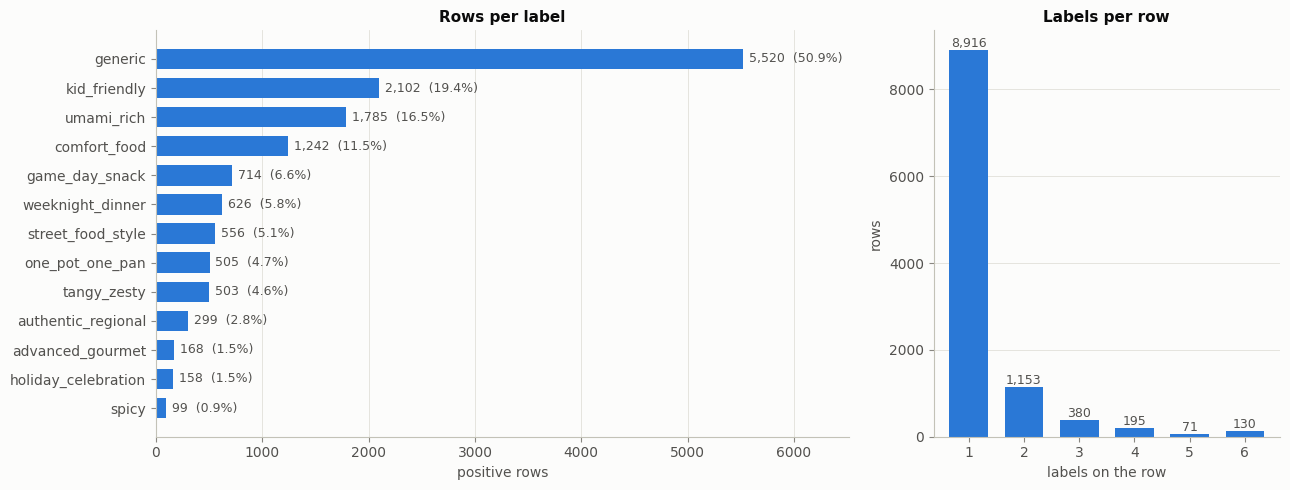

In [33]:
import matplotlib.pyplot as plt

# chart chrome (reference palette: light surface, recessive axes, categorical slots in fixed order)
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SERIES = ["#2a78d6", "#eb6834"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})

label_counts = Y.sum().sort_values(ascending=False)
label_balance = pd.DataFrame({
    "positives": label_counts,
    "prevalence_%": (100 * label_counts / len(Y)).round(2),
    "imbalance_vs_max": (label_counts.max() / label_counts).round(1),
})
labels_per_row = Y.sum(axis=1)
print(f"rows {len(Y)}, labels/row mean {labels_per_row.mean():.2f}, "
      f"max imbalance {label_balance['imbalance_vs_max'].max():.0f}:1 "
      f"({label_counts.index[0]} vs {label_counts.index[-1]})")
display(label_balance)

fig, (ax_bal, ax_card) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2, 1]})
order = label_counts.sort_values()
bars = ax_bal.barh(order.index, order.values, color=SERIES[0], height=0.7)
for bar, (name, cnt) in zip(bars, order.items()):
    ax_bal.text(bar.get_width() + label_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{cnt:,}  ({100 * cnt / len(Y):.1f}%)", va="center", fontsize=9, color=INK_2)
ax_bal.set_xlim(0, label_counts.max() * 1.18)
ax_bal.grid(axis="y", visible=False)
ax_bal.set_xlabel("positive rows")
ax_bal.set_title("Rows per label")

card = labels_per_row.value_counts().sort_index()
ax_card.bar(card.index.astype(str), card.values, color=SERIES[0], width=0.7)
for x, v in zip(card.index.astype(str), card.values):
    ax_card.text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK_2)
ax_card.grid(axis="x", visible=False)
ax_card.set_xlabel("labels on the row")
ax_card.set_ylabel("rows")
ax_card.set_title("Labels per row")
fig.tight_layout()
plt.show()

## Generic gate + classifier chain over attention embeddings + nutrient PCA

```text
product / adj / verb terms ──MiniLM (frozen)──► self-attention within each item ──pool──► EMB_DIM vector ─┐
nutrients ──log1p──► StandardScaler ──► PCA (NUTRIENT_PCA_VARIANCE) ───────────────────────────────────────┴─► concat ─┐
                                                                                                                         ▼
                                                    generic gate (LogisticRegression, generic vs not) ──generic──► {generic}, stop
                                                                         │ not generic
                                                                         ▼
                                                    ClassifierChain(LogisticRegression) over the 12 specific labels
```

- `generic` (~51% of rows) is exclusive, so it is not a chain link: a binary gate decides generic vs not, and only
  non-generic rows reach the chain. The chain is trained on non-generic train rows only. A row the gate sends to the chain
  always gets at least one label (its most likely one, if no chain link fires).

- Each item is its own attention sequence (padding is masked), so terms only attend to terms of the same item.
  A learned type embedding marks each term as product, adj or verb.
- The encoder is trained on the train-split labels (multi-label BCE head), then its pooled vectors are the item embeddings.
  One encoder embeds every row: out-of-fold encoders would each learn their own embedding space, which the chain cannot
  combine. Encoder, scaler, PCA and chain are fit on the train split only.
- Rare labels (e.g. `spicy`, 99 rows) are handled by `class_weight="balanced"` in each chain link and `pos_weight` in the encoder loss.
- Caveat: the silver labels were produced by rules over the same description/product/adj/verb text and nutrient thresholds,
  so these scores measure how well the rules are recovered, not true label quality.

In [34]:
import ast
import random

import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

RANDOM_STATE = 42
TEST_SIZE = 0.2
TERM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # Frozen vector per product / adj / verb term.
TERM_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
TOKEN_TYPES = ["product", "adj", "verb"]
EMB_DIM = 64
ATTENTION_HEADS = 4
ENCODER_EPOCHS = 20
ENCODER_BATCH_SIZE = 256
ENCODER_LR = 1e-3
MAX_POS_WEIGHT = 50.0
NUTRIENT_COLS = ["protein_g", "fat_g", "carb_g", "energy_kcal", "fiber_g", "sodium_mg",
                 "cholesterol_mg", "satfat_g", "sugars_g"]
NUTRIENT_PCA_VARIANCE = 0.95

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

In [35]:
# ---------- terms per item ----------
def parse_terms(col):
    return recipe_classes_df[col].fillna("[]").apply(ast.literal_eval).apply(
        lambda xs: [str(x).strip().lower() for x in xs if str(x).strip()])

item_terms = []  # per item: list of (term, type index)
for row in zip(*(parse_terms(c) for c in TOKEN_TYPES)):
    item_terms.append([(t, k) for k, terms in enumerate(row) for t in terms])

vocab = sorted({t for terms in item_terms for t, _ in terms})
term_index = {t: i + 1 for i, t in enumerate(vocab)}  # 0 = padding
term_model = SentenceTransformer(TERM_MODEL, revision=TERM_REVISION, device="cpu")
term_vectors = term_model.encode(vocab, batch_size=256, normalize_embeddings=True, show_progress_bar=False)
term_vectors = np.vstack([np.zeros((1, term_vectors.shape[1]), dtype=np.float32), term_vectors])

max_len = max(len(terms) for terms in item_terms)
term_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
type_ids = np.zeros((len(item_terms), max_len), dtype=np.int64)
for i, terms in enumerate(item_terms):
    for j, (t, k) in enumerate(terms):
        term_ids[i, j] = term_index[t]
        type_ids[i, j] = k
assert (term_ids[:, 0] > 0).all()  # every item has at least one term
print(f"{len(vocab)} terms, max {max_len} per item")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2977 terms, max 14 per item


In [36]:
class ItemAttentionEncoder(nn.Module):
    """Self-attention over one item's product/adj/verb terms, masked-mean pooled to EMB_DIM."""

    def __init__(self, term_vectors, n_labels):
        super().__init__()
        self.term_emb = nn.Embedding.from_pretrained(torch.tensor(term_vectors), freeze=True, padding_idx=0)
        self.proj = nn.Linear(term_vectors.shape[1], EMB_DIM)
        self.type_emb = nn.Embedding(len(TOKEN_TYPES), EMB_DIM)
        self.attn = nn.MultiheadAttention(EMB_DIM, ATTENTION_HEADS, dropout=0.1, batch_first=True)
        self.norm1 = nn.LayerNorm(EMB_DIM)
        self.ff = nn.Sequential(nn.Linear(EMB_DIM, 2 * EMB_DIM), nn.GELU(), nn.Linear(2 * EMB_DIM, EMB_DIM))
        self.norm2 = nn.LayerNorm(EMB_DIM)
        self.head = nn.Linear(EMB_DIM, n_labels)

    def embed(self, term_ids, type_ids):
        pad = term_ids == 0
        x = self.proj(self.term_emb(term_ids)) + self.type_emb(type_ids)
        a, _ = self.attn(x, x, x, key_padding_mask=pad)  # a term only sees terms of its own item
        x = self.norm1(x + a)
        x = self.norm2(x + self.ff(x))
        keep = (~pad).unsqueeze(-1).float()
        return (x * keep).sum(1) / keep.sum(1)

    def forward(self, term_ids, type_ids):
        return self.head(self.embed(term_ids, type_ids))


def fit_encoder(idx, Y_np):
    model = ItemAttentionEncoder(term_vectors, Y_np.shape[1])
    y = torch.tensor(Y_np[idx], dtype=torch.float32)
    pos = y.sum(0)
    pos_weight = ((len(y) - pos) / pos.clamp(min=1)).clamp(max=MAX_POS_WEIGHT)
    terms, types = torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])
    opt = torch.optim.AdamW(model.parameters(), lr=ENCODER_LR, weight_decay=1e-4)
    model.train()
    for epoch in range(ENCODER_EPOCHS):
        perm = torch.randperm(len(idx))
        for b in range(0, len(idx), ENCODER_BATCH_SIZE):
            bi = perm[b:b + ENCODER_BATCH_SIZE]
            loss = F.binary_cross_entropy_with_logits(model(terms[bi], types[bi]), y[bi], pos_weight=pos_weight)
            opt.zero_grad()
            loss.backward()
            opt.step()
    return model.eval()


@torch.no_grad()
def encode(model, idx):
    return model.embed(torch.tensor(term_ids[idx]), torch.tensor(type_ids[idx])).numpy()

In [37]:
# ---------- split + item embeddings ----------
Y_np = Y[LABEL_COLS].to_numpy()
train_idx, test_idx = train_test_split(np.arange(len(Y_np)), test_size=TEST_SIZE, random_state=RANDOM_STATE)

encoder = fit_encoder(train_idx, Y_np)
item_emb = encode(encoder, np.arange(len(Y_np)))

In [38]:
# ---------- label balance across the split: rare labels must still have test positives ----------
split_balance = pd.DataFrame({
    "train_%": (100 * Y_np[train_idx].mean(0)).round(2),
    "test_%": (100 * Y_np[test_idx].mean(0)).round(2),
    "test_positives": Y_np[test_idx].sum(0),
}, index=LABEL_COLS).sort_values("test_positives")
split_balance["diff_pp"] = (split_balance["test_%"] - split_balance["train_%"]).round(2)
display(split_balance)

,train_%,test_%,test_positives,diff_pp
spicy,0.93,0.83,18,-0.10
holiday_celebration,1.43,1.57,34,0.14
advanced_gourmet,1.45,1.94,42,0.49
authentic_regional,2.65,3.18,69,0.53
street_food_style,5.23,4.70,102,-0.53
one_pot_one_pan,4.60,4.89,106,0.29
tangy_zesty,4.55,4.98,108,0.43
weeknight_dinner,5.83,5.53,120,-0.30
game_day_snack,6.71,6.09,132,-0.62
comfort_food,11.55,11.07,240,-0.48


In [39]:
# ---------- nutrients: log1p (heavy right tail, e.g. sodium up to 38,758 mg) → standardize → PCA ----------
nutrients = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0))
nutrients = nutrients.fillna(nutrients.iloc[train_idx].median()).to_numpy()

nutrient_scaler = StandardScaler().fit(nutrients[train_idx])
nutrient_pca = PCA(n_components=NUTRIENT_PCA_VARIANCE, random_state=RANDOM_STATE).fit(
    nutrient_scaler.transform(nutrients[train_idx]))
nutrient_pcs = nutrient_pca.transform(nutrient_scaler.transform(nutrients))
print(f"{nutrient_pca.n_components_} PCs, explained variance {nutrient_pca.explained_variance_ratio_.sum():.3f}")

6 PCs, explained variance 0.961


## Nutrient variance before / after standardization

Raw nutrients sit on very different scales (sodium in mg vs fiber in g), so without scaling PCA would just follow sodium.
log1p tames the right tail; `StandardScaler` then gives every nutrient mean 0 / variance 1 on the train rows.

,raw_var,log1p_var,standardized_var,standardized_mean,raw_share_%
protein_g,102.2,1.084,1.000,1.5e-16,0.01
fat_g,235.8,1.301,1.000,1.9e-15,0.03
carb_g,551.9,2.207,1.000,8.1e-15,0.07
energy_kcal,"26,189.0",0.981,1.000,-1.1e-14,3.41
fiber_g,13.6,0.559,1.000,-8.3e-15,0.00
sodium_mg,"727,226.3",3.073,1.000,1.1e-14,94.76
cholesterol_mg,"12,951.3",3.969,1.000,-4.0e-15,1.69
satfat_g,35.4,0.706,1.000,-6.7e-16,0.00
sugars_g,147.7,1.171,1.000,4.4e-15,0.02


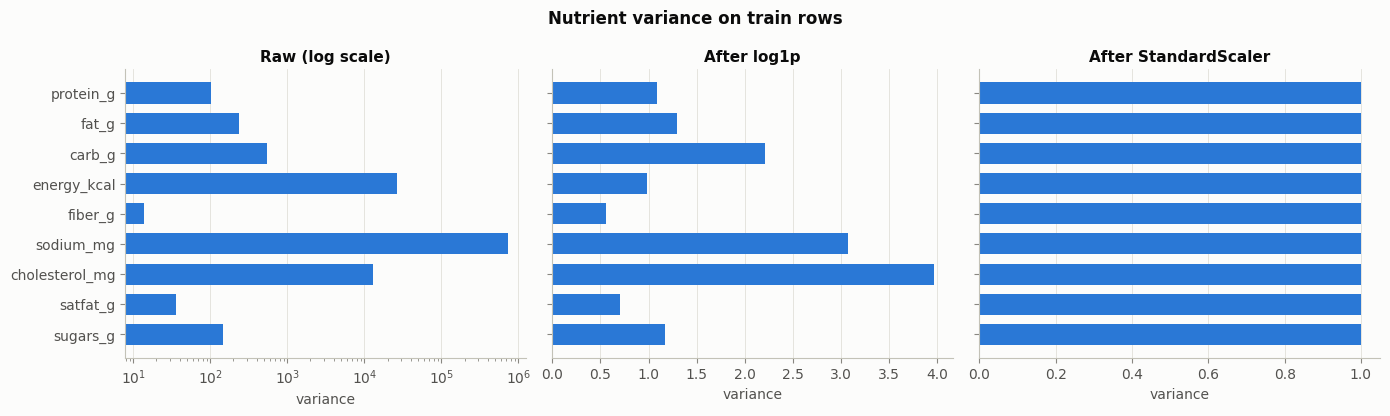

In [40]:
nutrients_raw = recipe_classes_df[NUTRIENT_COLS].iloc[train_idx]
nutrients_log = nutrients[train_idx]                    # after log1p + median fill
nutrients_std = nutrient_scaler.transform(nutrients_log)  # after StandardScaler

nutrient_variance = pd.DataFrame({
    "raw_var": nutrients_raw.var(ddof=0),
    "log1p_var": nutrients_log.var(0),
    "standardized_var": nutrients_std.var(0),
    "standardized_mean": nutrients_std.mean(0),
}, index=NUTRIENT_COLS)
nutrient_variance["raw_share_%"] = 100 * nutrient_variance["raw_var"] / nutrient_variance["raw_var"].sum()
display(nutrient_variance.style.format({
    "raw_var": "{:,.1f}", "log1p_var": "{:.3f}", "standardized_var": "{:.3f}",
    "standardized_mean": "{:.1e}", "raw_share_%": "{:.2f}"}))
assert np.allclose(nutrients_std.var(0), 1, atol=1e-6) and np.allclose(nutrients_std.mean(0), 0, atol=1e-6)

# one panel per stage: the stages differ by orders of magnitude, so they never share an axis
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
stages = [("raw_var", "Raw (log scale)"), ("log1p_var", "After log1p"), ("standardized_var", "After StandardScaler")]
for ax, (col, title) in zip(axes, stages):
    ax.barh(NUTRIENT_COLS, nutrient_variance[col], color=SERIES[0], height=0.7)
    ax.set_title(title)
    ax.set_xlabel("variance")
    ax.grid(axis="y", visible=False)
axes[0].set_xscale("log")
axes[0].invert_yaxis()
fig.suptitle("Nutrient variance on train rows", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

## Nutrient PCA

Scree (how much variance each component keeps; the kept ones are those needed for `NUTRIENT_PCA_VARIANCE`),
the first two components colored by generic vs labelled items, and the loadings of the kept components.

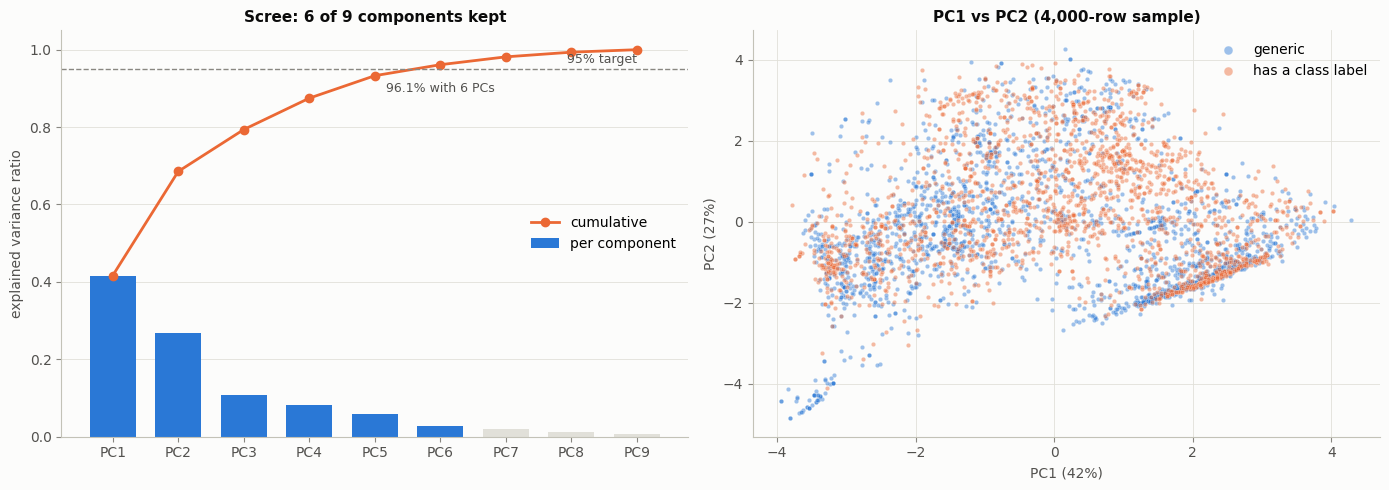

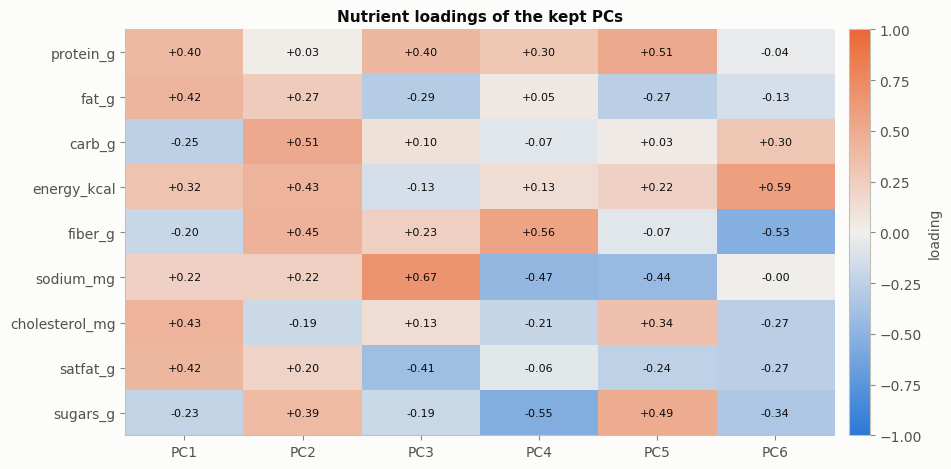

In [41]:
from matplotlib.colors import LinearSegmentedColormap

pca_full = PCA(random_state=RANDOM_STATE).fit(nutrients_std)  # all components, only for the scree plot
evr = pca_full.explained_variance_ratio_
k = nutrient_pca.n_components_
pc_names = [f"PC{i + 1}" for i in range(len(evr))]

fig, (ax_scree, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))
ax_scree.bar(pc_names, evr, color=[SERIES[0] if i < k else GRID for i in range(len(evr))], width=0.7,
             label="per component")
ax_scree.plot(pc_names, np.cumsum(evr), color=SERIES[1], lw=2, marker="o", ms=6, label="cumulative")
ax_scree.axhline(NUTRIENT_PCA_VARIANCE, color=MUTED, lw=1, ls="--")
ax_scree.text(len(evr) - 1, NUTRIENT_PCA_VARIANCE + 0.015, f"{NUTRIENT_PCA_VARIANCE:.0%} target",
              ha="right", fontsize=9, color=INK_2)
ax_scree.annotate(f"{np.cumsum(evr)[k - 1]:.1%} with {k} PCs", (k - 1, np.cumsum(evr)[k - 1]),
                  xytext=(0, -20), textcoords="offset points", ha="center", fontsize=9, color=INK_2)
ax_scree.set_ylim(0, 1.05)
ax_scree.set_ylabel("explained variance ratio")
ax_scree.grid(axis="x", visible=False)
ax_scree.legend(loc="center right")
ax_scree.set_title(f"Scree: {k} of {len(evr)} components kept")

rng = np.random.default_rng(RANDOM_STATE)
sample = rng.choice(len(nutrient_pcs), size=min(4000, len(nutrient_pcs)), replace=False)
is_generic = Y["generic"].to_numpy()[sample] == 1
for mask, name, color in [(is_generic, "generic", SERIES[0]), (~is_generic, "has a class label", SERIES[1])]:
    ax_scatter.scatter(nutrient_pcs[sample][mask, 0], nutrient_pcs[sample][mask, 1], s=10, alpha=0.45,
                       color=color, edgecolors=SURFACE, linewidths=0.3, label=name)
ax_scatter.set_xlabel(f"PC1 ({evr[0]:.0%})")
ax_scatter.set_ylabel(f"PC2 ({evr[1]:.0%})")
ax_scatter.legend(markerscale=2)
ax_scatter.set_title("PC1 vs PC2 (4,000-row sample)")
fig.tight_layout()
plt.show()

# loadings of the kept components: diverging blue / neutral / orange, centred on 0
diverging = LinearSegmentedColormap.from_list("div", [SERIES[0], "#f0efec", SERIES[1]])
loadings = pd.DataFrame(nutrient_pca.components_.T, index=NUTRIENT_COLS, columns=pc_names[:k])
fig, ax = plt.subplots(figsize=(1.1 * k + 3, 4.8))
im = ax.imshow(loadings.values, cmap=diverging, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(k), loadings.columns)
ax.set_yticks(range(len(NUTRIENT_COLS)), NUTRIENT_COLS)
ax.grid(False)
for (i, j), v in np.ndenumerate(loadings.values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color=INK)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="loading")
ax.set_title("Nutrient loadings of the kept PCs")
fig.tight_layout()
plt.show()

In [42]:
# ---------- concat → generic gate → classifier chain ----------
X = np.hstack([item_emb, nutrient_pcs])
feature_scaler = StandardScaler().fit(X[train_idx])
X = feature_scaler.transform(X)

GENERIC = LABEL_COLS.index("generic")
CHAIN_LABELS = [c for c in LABEL_COLS if c != "generic"]
chain_cols = [LABEL_COLS.index(c) for c in CHAIN_LABELS]

# stage 1: generic vs not
generic_gate = LogisticRegression(class_weight="balanced", max_iter=2000).fit(X[train_idx], Y_np[train_idx, GENERIC])

# stage 2: chain over the specific labels, trained on non-generic rows only
specific_train_idx = train_idx[Y_np[train_idx, GENERIC] == 0]
Y_specific = Y_np[np.ix_(specific_train_idx, chain_cols)]
chain_order = np.argsort(-Y_specific.sum(0))  # most frequent label first
chain = ClassifierChain(
    LogisticRegression(class_weight="balanced", max_iter=2000),
    order=chain_order,
    random_state=RANDOM_STATE,
).fit(X[specific_train_idx], Y_specific)


def predict_labels(X_rows, gate, chain):
    """Gate first: generic rows get only `generic`; the rest get the chain's labels (at least one)."""
    out = np.zeros((len(X_rows), len(LABEL_COLS)), dtype=int)
    gated_generic = gate.predict(X_rows).astype(bool)
    out[gated_generic, GENERIC] = 1
    specific_rows = np.flatnonzero(~gated_generic)
    if len(specific_rows):
        pred = chain.predict(X_rows[specific_rows]).astype(int)
        empty = pred.sum(1) == 0
        if empty.any():
            pred[empty, chain.predict_proba(X_rows[specific_rows[empty]]).argmax(1)] = 1
        out[np.ix_(specific_rows, chain_cols)] = pred
    return out


Y_pred = predict_labels(X[test_idx], generic_gate, chain)
Y_true = Y_np[test_idx]

gate_pred = generic_gate.predict(X[test_idx])
print(f"generic gate: accuracy {accuracy_score(Y_true[:, GENERIC], gate_pred):.3f}  "
      f"F1 {f1_score(Y_true[:, GENERIC], gate_pred):.3f}")
specific_test = Y_true[:, GENERIC] == 0  # chain alone, on rows that truly are non-generic
chain_only = chain.predict(X[test_idx][specific_test]).astype(int)
print(f"chain on true non-generic rows: micro F1 {f1_score(Y_true[specific_test][:, chain_cols], chain_only, average='micro'):.3f}  "
      f"macro F1 {f1_score(Y_true[specific_test][:, chain_cols], chain_only, average='macro'):.3f}")
print("end to end:")
print(f"X: {X.shape}  (item embedding {EMB_DIM} + nutrient PCs {nutrient_pcs.shape[1]})")
print(f"micro F1 {f1_score(Y_true, Y_pred, average='micro'):.3f}  "
      f"macro F1 {f1_score(Y_true, Y_pred, average='macro'):.3f}  "
      f"hamming loss {hamming_loss(Y_true, Y_pred):.3f}  "
      f"exact match {accuracy_score(Y_true, Y_pred):.3f}")
print(classification_report(Y_true, Y_pred, target_names=LABEL_COLS, zero_division=0))

generic gate: accuracy 0.827  F1 0.830
chain on true non-generic rows: micro F1 0.760  macro F1 0.687
end to end:
X: (10845, 70)  (item embedding 64 + nutrient PCs 6)
micro F1 0.724  macro F1 0.606  hamming loss 0.061  exact match 0.618
                     precision    recall  f1-score   support

   advanced_gourmet       0.30      0.67      0.42        42
 authentic_regional       0.34      0.58      0.43        69
       comfort_food       0.59      0.77      0.67       240
     game_day_snack       0.61      0.84      0.71       132
            generic       0.82      0.84      0.83      1091
holiday_celebration       0.38      0.53      0.44        34
       kid_friendly       0.79      0.85      0.82       398
    one_pot_one_pan       0.45      0.74      0.56       106
              spicy       0.30      0.61      0.40        18
  street_food_style       0.57      0.93      0.71       102
        tangy_zesty       0.48      0.58      0.53       108
         umami_rich       0.64

## Save weights

`model_artifacts/recipe_classifier/`:
- `recipe_classifier.pt`: attention encoder `state_dict`, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient train medians, nutrient scaler, PCA, feature scaler, generic gate, classifier chain.
- `config.json`: label order, dropped labels, settings and test metrics.

The last lines reload the files and check they reproduce the test predictions.

In [43]:
import json
from pathlib import Path

import joblib

ARTIFACT_DIR = Path("model_artifacts/recipe_classifier")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

encoder_config = {"emb_dim": EMB_DIM, "attention_heads": ATTENTION_HEADS, "token_types": TOKEN_TYPES,
                  "max_len": max_len, "n_labels": len(LABEL_COLS)}
torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
            "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
           ARTIFACT_DIR / "recipe_classifier.pt")
joblib.dump({"nutrient_cols": NUTRIENT_COLS,
             "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
             "nutrient_scaler": nutrient_scaler, "nutrient_pca": nutrient_pca,
             "feature_scaler": feature_scaler, "generic_gate": generic_gate, "chain": chain},
            ARTIFACT_DIR / "preprocessing.joblib")
(ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "gate_label": "generic",
    "chain_labels": CHAIN_LABELS, "chain_order": chain_order.tolist(),
    "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
    "encoder_epochs": ENCODER_EPOCHS, "encoder_lr": ENCODER_LR, "nutrient_pca_variance": NUTRIENT_PCA_VARIANCE,
    "test_metrics": {"micro_f1": f1_score(Y_true, Y_pred, average="micro"),
                     "macro_f1": f1_score(Y_true, Y_pred, average="macro"),
                     "hamming_loss": hamming_loss(Y_true, Y_pred),
                     "exact_match": accuracy_score(Y_true, Y_pred)},
}, indent=2))

# reload and check the saved files reproduce the test predictions
saved = torch.load(ARTIFACT_DIR / "recipe_classifier.pt", weights_only=False)
reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
reloaded.load_state_dict(saved["state_dict"])
reloaded.eval()
prep = joblib.load(ARTIFACT_DIR / "preprocessing.joblib")
with torch.no_grad():
    emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
pcs = prep["nutrient_pca"].transform(prep["nutrient_scaler"].transform(nut))
X_re = prep["feature_scaler"].transform(np.hstack([emb, pcs]))
assert (predict_labels(X_re, prep["generic_gate"], prep["chain"]) == Y_pred).all()
print("saved to", ARTIFACT_DIR, sorted(p.name for p in ARTIFACT_DIR.iterdir()))

saved to model_artifacts/recipe_classifier ['config.json', 'preprocessing.joblib', 'recipe_classifier.pt']


## Model comparison: setup

Every model below uses the same features `X` (item embedding + nutrient PCs), the same train/test split and the same
13 labels as the logistic-regression model above. Each model follows the same pipeline:
a binary `generic` gate, then a classifier chain over the 12 specific labels trained on non-generic rows
(`predict_labels`). The same estimator type is used for the gate and every chain link. Results go into `model_results`
for the comparison section at the end.

In [44]:
# Run once if xgboost is missing, then restart the kernel.
# %pip install xgboost
import time

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

model_results = {}  # model name -> test predictions and fit time


def record_result(name, pred, fit_seconds, results=model_results):
    results[name] = {"pred": pred, "fit_seconds": fit_seconds}
    print(f"{name}: fit {fit_seconds:.1f}s  "
          f"micro F1 {f1_score(Y_true, pred, average='micro'):.3f}  "
          f"macro F1 {f1_score(Y_true, pred, average='macro'):.3f}  "
          f"exact match {accuracy_score(Y_true, pred):.3f}")
    print(classification_report(Y_true, pred, target_names=LABEL_COLS, zero_division=0))


def run_gated_chain(name, estimator):
    """Fit `estimator` as the generic gate and as every chain link, then score it on the test split."""
    start = time.perf_counter()
    gate = clone(estimator).fit(X[train_idx], Y_np[train_idx, GENERIC])
    gated_chain = ClassifierChain(clone(estimator), order=chain_order, random_state=RANDOM_STATE).fit(
        X[specific_train_idx], Y_specific)
    fit_seconds = time.perf_counter() - start
    record_result(name, predict_labels(X[test_idx], gate, gated_chain), fit_seconds)
    return gate, gated_chain


# the logistic-regression model from above, refit here so its fit time is measured the same way
lr_gate, lr_chain = run_gated_chain("Logistic regression", LogisticRegression(class_weight="balanced", max_iter=2000))
assert (model_results["Logistic regression"]["pred"] == Y_pred).all()

Logistic regression: fit 0.3s  micro F1 0.724  macro F1 0.606  exact match 0.618
                     precision    recall  f1-score   support

   advanced_gourmet       0.30      0.67      0.42        42
 authentic_regional       0.34      0.58      0.43        69
       comfort_food       0.59      0.77      0.67       240
     game_day_snack       0.61      0.84      0.71       132
            generic       0.82      0.84      0.83      1091
holiday_celebration       0.38      0.53      0.44        34
       kid_friendly       0.79      0.85      0.82       398
    one_pot_one_pan       0.45      0.74      0.56       106
              spicy       0.30      0.61      0.40        18
  street_food_style       0.57      0.93      0.71       102
        tangy_zesty       0.48      0.58      0.53       108
         umami_rich       0.64      0.75      0.69       354
   weeknight_dinner       0.56      0.87      0.68       120

          micro avg       0.66      0.80      0.72      2814
  

## KNN

`KNeighborsClassifier` with 15 distance-weighted neighbours. KNN has no class weights, so rare labels
(e.g. `spicy`) are only predicted when most close neighbours have them.

In [45]:
knn_gate, knn_chain = run_gated_chain("KNN", KNeighborsClassifier(n_neighbors=15, weights="distance"))

KNN: fit 0.1s  micro F1 0.822  macro F1 0.727  exact match 0.767
                     precision    recall  f1-score   support

   advanced_gourmet       0.88      0.50      0.64        42
 authentic_regional       0.74      0.46      0.57        69
       comfort_food       0.78      0.70      0.74       240
     game_day_snack       0.90      0.79      0.84       132
            generic       0.86      0.90      0.88      1091
holiday_celebration       0.80      0.47      0.59        34
       kid_friendly       0.87      0.87      0.87       398
    one_pot_one_pan       0.82      0.69      0.75       106
              spicy       0.86      0.33      0.48        18
  street_food_style       0.85      0.80      0.83       102
        tangy_zesty       0.84      0.65      0.73       108
         umami_rich       0.78      0.77      0.77       354
   weeknight_dinner       0.81      0.72      0.76       120

          micro avg       0.84      0.80      0.82      2814
          macro av

### KNN decision boundaries

`X` has 70 dimensions, so a boundary can't be drawn directly. The plot projects `X` onto its first two principal
components (fit on train rows) and refits a KNN with the **same settings** on those two coordinates. The shaded
regions are that 2-D surrogate's boundary, not the 70-D model's; the printed accuracies show how much is lost.
Left: the `generic` gate (all train rows). Right: the `kid_friendly` chain link (non-generic train rows).

generic: 2-D surrogate test accuracy 0.801
kid_friendly: 2-D surrogate test accuracy 0.837
real 70-D KNN gate test accuracy 0.878


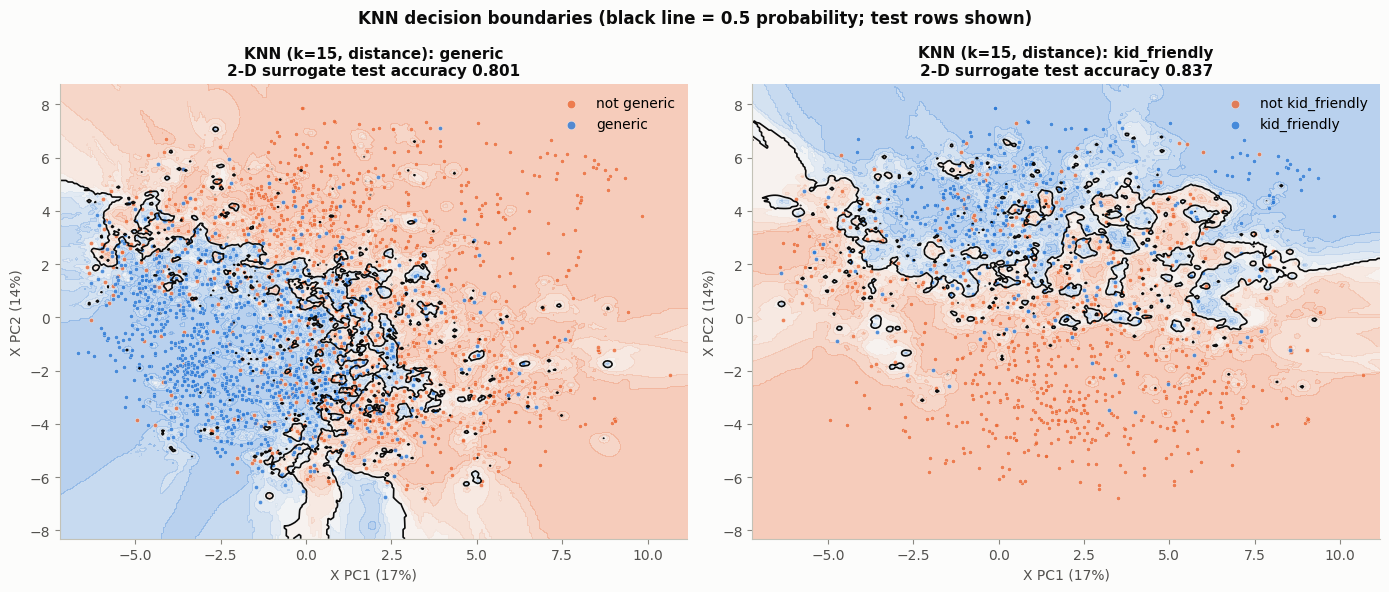

In [46]:
from matplotlib.colors import LinearSegmentedColormap

viz_proj = PCA(n_components=2, random_state=RANDOM_STATE).fit(X[train_idx])
viz_X2 = viz_proj.transform(X)
viz_region_cmap = LinearSegmentedColormap.from_list("region", [SERIES[1], "#f0efec", SERIES[0]])
viz_rng = np.random.default_rng(RANDOM_STATE)
viz_pad = 0.5
viz_xx, viz_yy = np.meshgrid(
    np.linspace(viz_X2[:, 0].min() - viz_pad, viz_X2[:, 0].max() + viz_pad, 300),
    np.linspace(viz_X2[:, 1].min() - viz_pad, viz_X2[:, 1].max() + viz_pad, 300))
viz_grid = np.c_[viz_xx.ravel(), viz_yy.ravel()]


def viz_targets(label):
    """(fit rows, test rows, y over all rows) for the gate or one chain link, as in the gated pipeline."""
    if label == "generic":
        return train_idx, test_idx, Y_np[:, GENERIC]
    test_rows = test_idx[Y_np[test_idx, GENERIC] == 0]
    return specific_train_idx, test_rows, Y_np[:, LABEL_COLS.index(label)]


def viz_scatter(ax, rows, y, label, n=2500):
    shown = viz_rng.choice(rows, size=min(n, len(rows)), replace=False)
    for cls, color, name in [(0, SERIES[1], f"not {label}"), (1, SERIES[0], label)]:
        pts = viz_X2[shown][y[shown] == cls]
        ax.scatter(pts[:, 0], pts[:, 1], s=9, color=color, edgecolors=SURFACE, linewidths=0.3, alpha=0.8, label=name)
    ax.set_xlabel(f"X PC1 ({viz_proj.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"X PC2 ({viz_proj.explained_variance_ratio_[1]:.0%})")
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, label in zip(axes, ["generic", "kid_friendly"]):
    fit_rows, test_rows, y = viz_targets(label)
    viz_knn = clone(knn_gate).fit(viz_X2[fit_rows], y[fit_rows])
    proba = viz_knn.predict_proba(viz_grid)[:, 1].reshape(viz_xx.shape)
    ax.contourf(viz_xx, viz_yy, proba, levels=np.linspace(0, 1, 11), cmap=viz_region_cmap, alpha=0.35)
    ax.contour(viz_xx, viz_yy, proba, levels=[0.5], colors=INK, linewidths=1.2)
    viz_scatter(ax, test_rows, y, label)
    acc_2d = accuracy_score(y[test_rows], viz_knn.predict(viz_X2[test_rows]))
    ax.set_title(f"KNN (k={knn_gate.n_neighbors}, {knn_gate.weights}): {label}\n"
                 f"2-D surrogate test accuracy {acc_2d:.3f}")
    ax.legend(loc="upper right", markerscale=2)
    print(f"{label}: 2-D surrogate test accuracy {acc_2d:.3f}")
print(f"real 70-D KNN gate test accuracy {accuracy_score(Y_np[test_idx, GENERIC], knn_gate.predict(X[test_idx])):.3f}")
fig.suptitle("KNN decision boundaries (black line = 0.5 probability; test rows shown)", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

## Decision Tree

`DecisionTreeClassifier` with balanced class weights and at least 5 rows per leaf, as the generic gate and every chain link.

In [47]:
dt_gate, dt_chain = run_gated_chain("Decision Tree", DecisionTreeClassifier(
    class_weight="balanced", min_samples_leaf=5, random_state=RANDOM_STATE))

Decision Tree: fit 2.9s  micro F1 0.716  macro F1 0.603  exact match 0.631
                     precision    recall  f1-score   support

   advanced_gourmet       0.31      0.55      0.40        42
 authentic_regional       0.39      0.59      0.47        69
       comfort_food       0.62      0.71      0.66       240
     game_day_snack       0.65      0.73      0.69       132
            generic       0.82      0.84      0.83      1091
holiday_celebration       0.57      0.50      0.53        34
       kid_friendly       0.76      0.81      0.78       398
    one_pot_one_pan       0.52      0.71      0.60       106
              spicy       0.33      0.56      0.42        18
  street_food_style       0.60      0.81      0.69       102
        tangy_zesty       0.48      0.53      0.50       108
         umami_rich       0.62      0.69      0.65       354
   weeknight_dinner       0.53      0.72      0.61       120

          micro avg       0.68      0.76      0.72      2814
        

### Decision tree structure

The top 3 levels of two trees: the `generic` gate (`dt_gate`, sees only `X`) and the `spicy` link of the chain
(`dt_chain`, late in the chain, so it can also split on the labels predicted before it, shown as `label:<name>`).
`emb_*` are attention-embedding dimensions and `nutrient_PC*` are nutrient principal components.
Each node shows the split, its weighted gini impurity, sample count and the class weights (`value`).

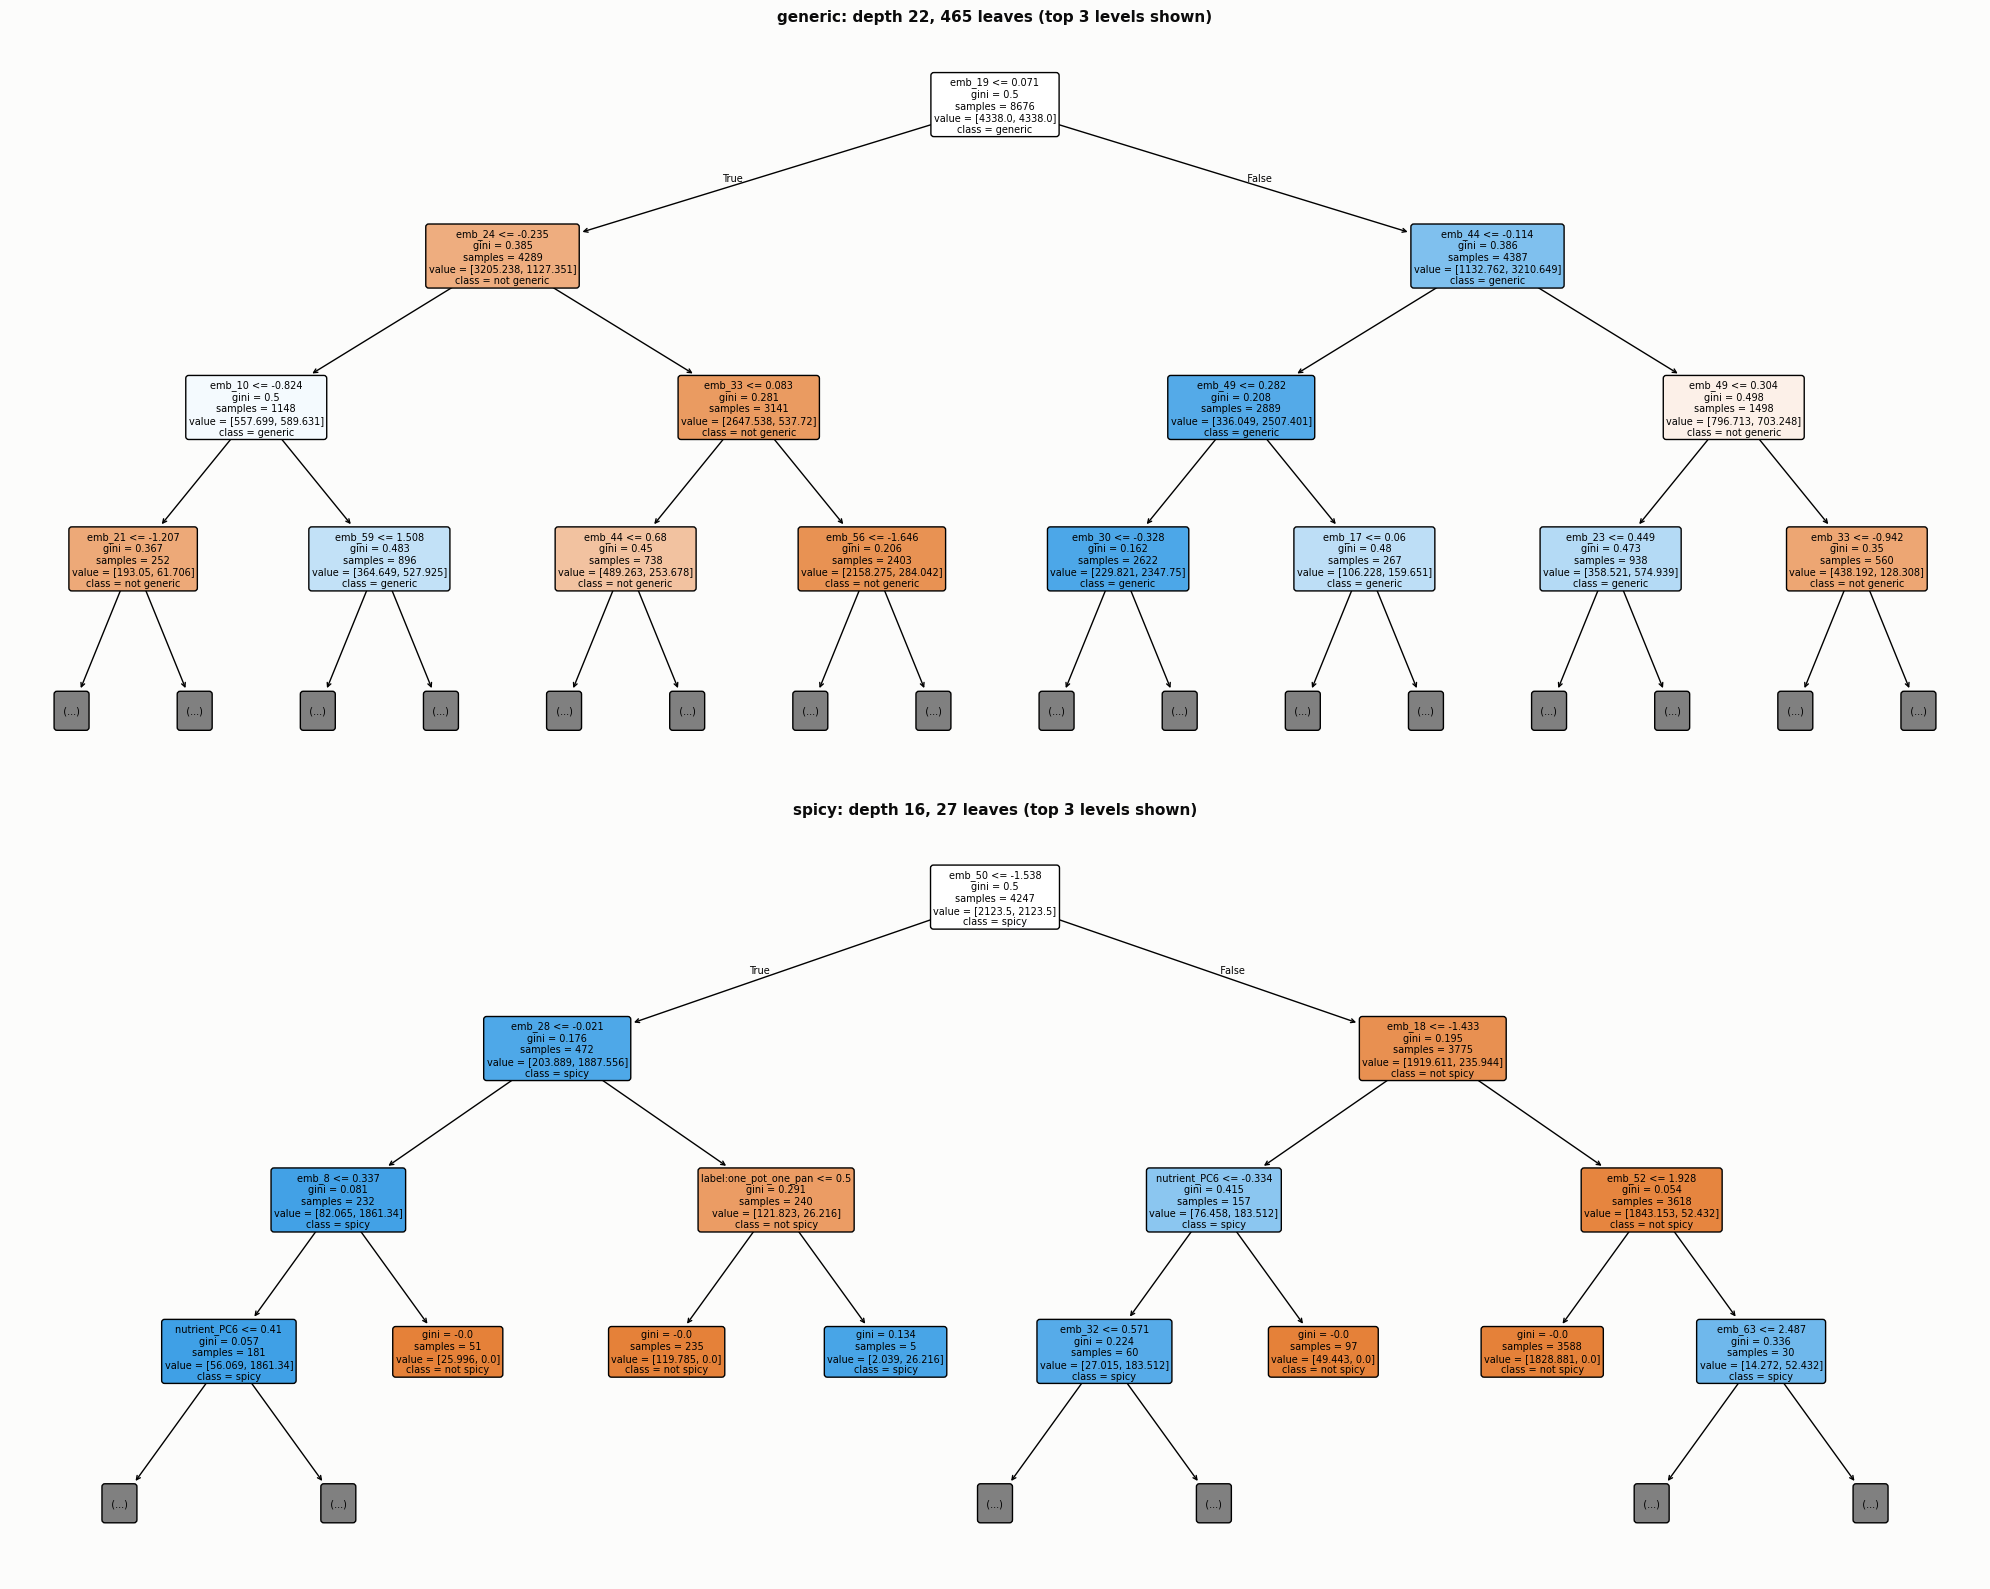

In [48]:
from sklearn.tree import plot_tree

viz_feature_names = [f"emb_{i}" for i in range(EMB_DIM)] + [f"nutrient_PC{i + 1}" for i in range(nutrient_pcs.shape[1])]


def viz_chain_feature_names(order, labels, position):
    """Features seen by chain link `position`: X, then the labels predicted before it in chain order."""
    return viz_feature_names + [f"label:{labels[j]}" for j in order[:position]]


def viz_plot_tree(ax, tree, feature_names, label, depth=3):
    plot_tree(tree, max_depth=depth, feature_names=feature_names, class_names=[f"not {label}", label],
              filled=True, rounded=True, impurity=True, proportion=False, fontsize=7, ax=ax)
    ax.set_title(f"{label}: depth {tree.get_depth()}, {tree.get_n_leaves()} leaves (top {depth} levels shown)")


fig, axes = plt.subplots(2, 1, figsize=(20, 16))
viz_plot_tree(axes[0], dt_gate, viz_feature_names, "generic")
viz_position = list(chain_order).index(CHAIN_LABELS.index("spicy"))
viz_plot_tree(axes[1], dt_chain.estimators_[viz_position],
              viz_chain_feature_names(chain_order, CHAIN_LABELS, viz_position), "spicy")
fig.tight_layout()
plt.show()

## SVM

RBF-kernel `SVC` with balanced class weights. `probability=True` is needed for the chain's fallback
(a non-generic row with no label gets its most likely one) and makes fitting slower (internal 5-fold Platt scaling).

In [49]:
svm_gate, svm_chain = run_gated_chain(
    "SVM", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE))

SVM: fit 14.3s  micro F1 0.791  macro F1 0.688  exact match 0.707
                     precision    recall  f1-score   support

   advanced_gourmet       0.38      0.67      0.49        42
 authentic_regional       0.42      0.67      0.51        69
       comfort_food       0.67      0.82      0.74       240
     game_day_snack       0.74      0.85      0.79       132
            generic       0.86      0.90      0.88      1091
holiday_celebration       0.46      0.62      0.53        34
       kid_friendly       0.86      0.87      0.87       398
    one_pot_one_pan       0.54      0.79      0.64       106
              spicy       0.45      0.78      0.57        18
  street_food_style       0.72      0.94      0.81       102
        tangy_zesty       0.58      0.74      0.65       108
         umami_rich       0.74      0.79      0.76       354
   weeknight_dinner       0.62      0.83      0.71       120

          micro avg       0.74      0.85      0.79      2814
          macro a

### SVM margin

Same 2-D projection as the KNN plot, so again a surrogate: an SVM with the model's settings is refit on the two
coordinates of a 3,000-row train sample (only the `generic` gate). The solid line is the decision boundary
(decision function = 0), the dashed lines are the margins (±1), and ringed points are support vectors.
Left: the model's RBF kernel. Right: a linear kernel for comparison, where the margin is a straight band.

real 70-D SVM gate test accuracy 0.876


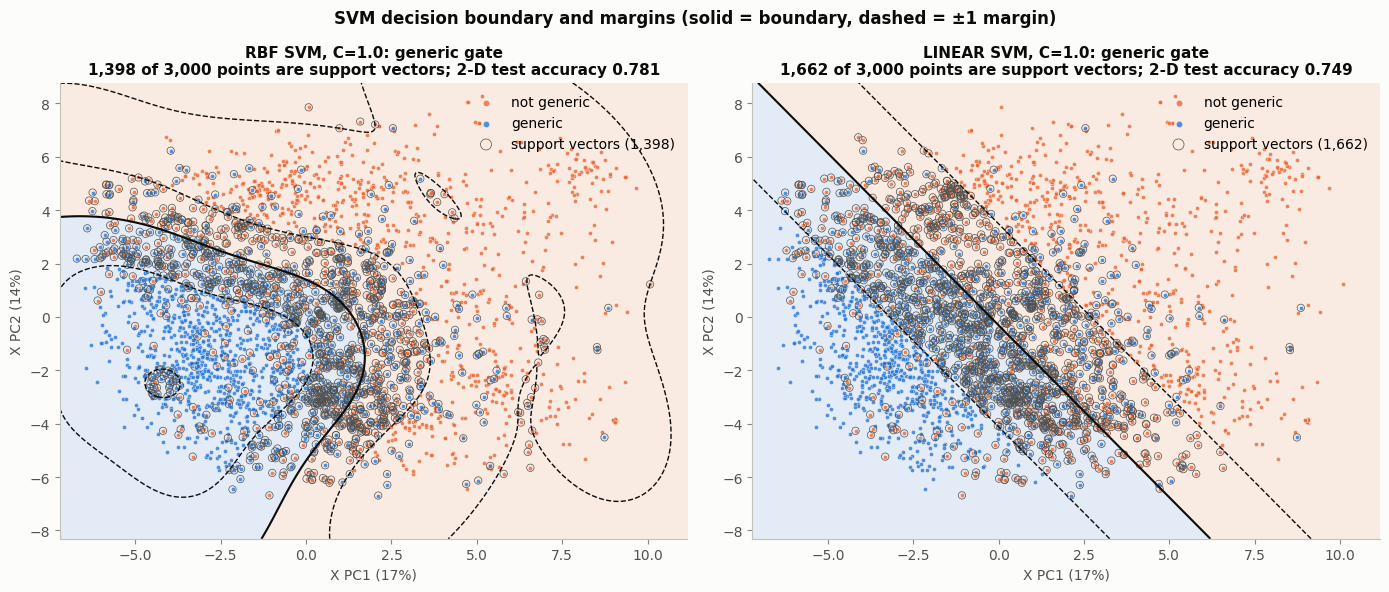

In [50]:
viz_fit_rows = viz_rng.choice(train_idx, size=3000, replace=False)
viz_y = Y_np[:, GENERIC]
viz_svm_params = {k: v for k, v in svm_gate.get_params().items() if k != "probability"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, kernel in zip(axes, ["rbf", "linear"]):
    viz_svm = SVC(**{**viz_svm_params, "kernel": kernel}).fit(viz_X2[viz_fit_rows], viz_y[viz_fit_rows])
    decision = viz_svm.decision_function(viz_grid).reshape(viz_xx.shape)
    ax.contourf(viz_xx, viz_yy, decision, levels=[-np.inf, 0, np.inf], colors=[SERIES[1], SERIES[0]], alpha=0.12)
    ax.contour(viz_xx, viz_yy, decision, levels=[-1, 0, 1], colors=INK, linestyles=["--", "-", "--"],
               linewidths=[1, 1.5, 1])
    viz_scatter(ax, viz_fit_rows, viz_y, "generic", n=len(viz_fit_rows))
    sv = viz_X2[viz_fit_rows][viz_svm.support_]
    ax.scatter(sv[:, 0], sv[:, 1], s=28, facecolors="none", edgecolors=INK_2, linewidths=0.5,
               label=f"support vectors ({len(sv):,})")
    test_acc = accuracy_score(viz_y[test_idx], viz_svm.predict(viz_X2[test_idx]))
    ax.set_title(f"{kernel.upper()} SVM, C={viz_svm.C}: generic gate\n"
                 f"{len(sv):,} of {len(viz_fit_rows):,} points are support vectors; 2-D test accuracy {test_acc:.3f}")
    ax.legend(loc="upper right", markerscale=1.5)
print(f"real 70-D SVM gate test accuracy {accuracy_score(Y_np[test_idx, GENERIC], svm_gate.predict(X[test_idx])):.3f}")
fig.suptitle("SVM decision boundary and margins (solid = boundary, dashed = ±1 margin)", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()

## XGBoost

The chain clones one estimator for every label, so `BalancedXGB` sets `scale_pos_weight` (negatives / positives)
from each label it is fitted on.

XGBoost segfaults in this process: torch is already loaded, and its OpenMP runtime clashes with XGBoost's
(same issue as LightGBM, and `n_jobs=1` does not avoid it). So the gate and chain are fitted and used for prediction
in a separate loky worker process that never imports torch; only the test predictions come back.

In [51]:
class BalancedXGB(ClassifierMixin, BaseEstimator):
    """XGBClassifier whose scale_pos_weight is set from the labels it is fitted on."""

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate

    def fit(self, X, y):
        pos = int(np.sum(y))
        self.model_ = XGBClassifier(
            n_estimators=self.n_estimators, max_depth=self.max_depth, learning_rate=self.learning_rate,
            scale_pos_weight=(len(y) - pos) / max(pos, 1), eval_metric="logloss",
            n_jobs=4, random_state=RANDOM_STATE,
        ).fit(X, y)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return self.model_.predict(X)

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


def fit_predict_gated_xgb(X_fit, y_gate, X_specific, Y_specific, X_test, order, gate=None):
    """Runs in the worker: fit the XGBoost chain (and the XGBoost gate unless `gate` is given),
    return test predictions and fit time."""
    start = time.perf_counter()
    if gate is None:
        gate = BalancedXGB().fit(X_fit, y_gate)
    gated_chain = ClassifierChain(BalancedXGB(), order=order, random_state=RANDOM_STATE).fit(X_specific, Y_specific)
    fit_seconds = time.perf_counter() - start
    return predict_labels(X_test, gate, gated_chain), fit_seconds


from joblib.externals.loky import get_reusable_executor

xgb_pred, xgb_seconds = get_reusable_executor(max_workers=1).submit(
    fit_predict_gated_xgb, X[train_idx], Y_np[train_idx, GENERIC], X[specific_train_idx], Y_specific,
    X[test_idx], chain_order,
).result()
record_result("XGBoost", xgb_pred, xgb_seconds)

XGBoost: fit 6.7s  micro F1 0.827  macro F1 0.746  exact match 0.764
                     precision    recall  f1-score   support

   advanced_gourmet       0.71      0.64      0.68        42
 authentic_regional       0.67      0.61      0.64        69
       comfort_food       0.75      0.78      0.76       240
     game_day_snack       0.83      0.80      0.82       132
            generic       0.87      0.89      0.88      1091
holiday_celebration       0.73      0.56      0.63        34
       kid_friendly       0.86      0.89      0.87       398
    one_pot_one_pan       0.77      0.74      0.75       106
              spicy       0.53      0.50      0.51        18
  street_food_style       0.83      0.86      0.85       102
        tangy_zesty       0.74      0.66      0.70       108
         umami_rich       0.78      0.83      0.80       354
   weeknight_dinner       0.80      0.82      0.81       120

          micro avg       0.82      0.83      0.83      2814
          macr

## Random Forest

300 trees with `class_weight="balanced_subsample"` (class weights recomputed on each bootstrap sample).

In [52]:
rf_gate, rf_chain = run_gated_chain("Random Forest", RandomForestClassifier(
    n_estimators=300, class_weight="balanced_subsample", min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))

Random Forest: fit 13.8s  micro F1 0.829  macro F1 0.737  exact match 0.765
                     precision    recall  f1-score   support

   advanced_gourmet       0.82      0.55      0.66        42
 authentic_regional       0.69      0.55      0.61        69
       comfort_food       0.79      0.71      0.75       240
     game_day_snack       0.87      0.82      0.84       132
            generic       0.88      0.89      0.89      1091
holiday_celebration       0.77      0.59      0.67        34
       kid_friendly       0.88      0.88      0.88       398
    one_pot_one_pan       0.84      0.73      0.78       106
              spicy       0.41      0.39      0.40        18
  street_food_style       0.86      0.81      0.83       102
        tangy_zesty       0.75      0.65      0.70       108
         umami_rich       0.78      0.80      0.79       354
   weeknight_dinner       0.84      0.75      0.79       120

          micro avg       0.84      0.82      0.83      2814
       

### Random Forest trees

One of the 300 trees of the `generic` gate (top 3 levels), and the gate's impurity-based feature importances
averaged over all its trees (top 15).

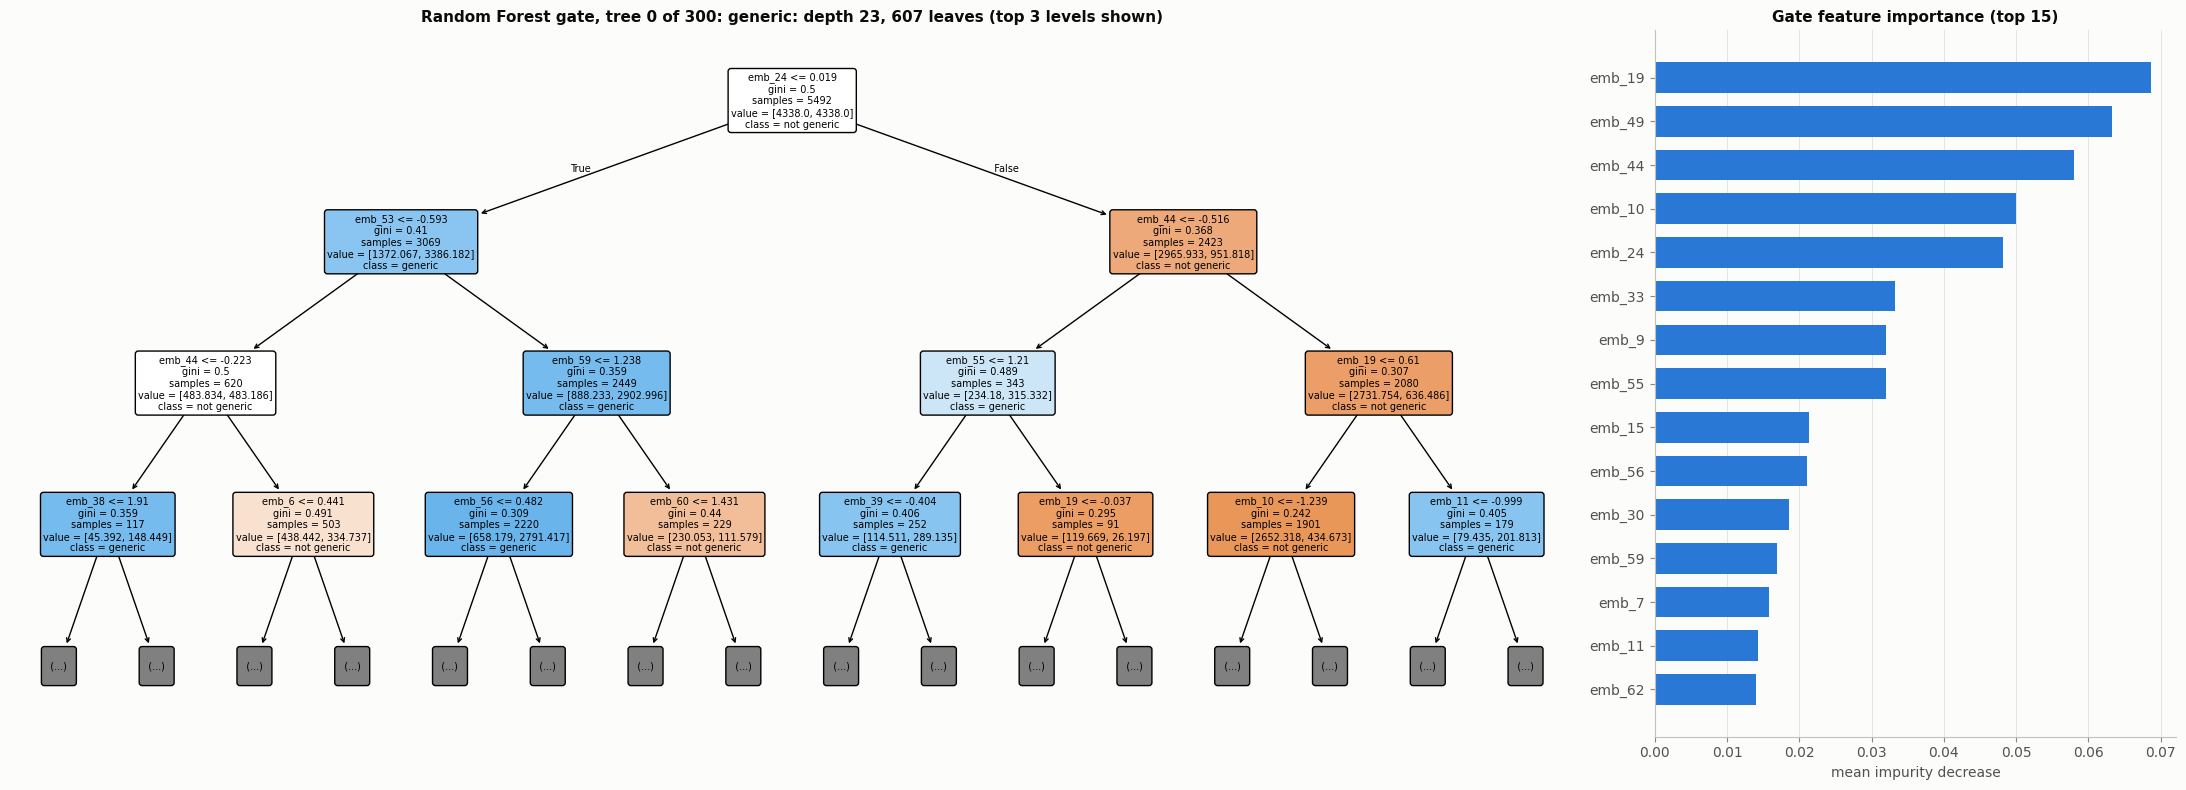

In [53]:
viz_rf_importance = pd.Series(rf_gate.feature_importances_, index=viz_feature_names).sort_values()

fig, (ax_tree, ax_imp) = plt.subplots(1, 2, figsize=(22, 8), gridspec_kw={"width_ratios": [3, 1]})
viz_plot_tree(ax_tree, rf_gate.estimators_[0], viz_feature_names, "generic")
ax_tree.set_title("Random Forest gate, tree 0 of " + f"{len(rf_gate.estimators_)}: " + ax_tree.get_title())
viz_top = viz_rf_importance.tail(15)
ax_imp.barh(viz_top.index, viz_top.values, color=SERIES[0], height=0.7)
ax_imp.grid(axis="y", visible=False)
ax_imp.set_xlabel("mean impurity decrease")
ax_imp.set_title("Gate feature importance (top 15)")
fig.tight_layout()
plt.show()

## Comparison

All scores are on the same test split (sorted by macro F1). Macro F1 weights every label equally, so it is the
fairest single number for the rare labels; micro F1 is dominated by `generic` and `kid_friendly`.
`no label` / `generic + other` count test rows that break the label rules (should stay 0 with a gate).
Same caveat as above: labels are rule-based silver labels, so this ranks how well each model recovers the rules.

In [54]:
def show_comparison(results):
    """Overall scores table and per-label F1 table for {name: {"pred", "fit_seconds"}}; returns the scores table."""
    table = pd.DataFrame({
        name: {
            "micro F1": f1_score(Y_true, r["pred"], average="micro"),
            "macro F1": f1_score(Y_true, r["pred"], average="macro"),
            "samples F1": f1_score(Y_true, r["pred"], average="samples", zero_division=0),
            "generic F1": f1_score(Y_true[:, GENERIC], r["pred"][:, GENERIC]),
            "hamming loss": hamming_loss(Y_true, r["pred"]),
            "exact match": accuracy_score(Y_true, r["pred"]),
            "no label": int((r["pred"].sum(1) == 0).sum()),
            "generic + other": int(((r["pred"][:, GENERIC] == 1) & (r["pred"].sum(1) > 1)).sum()),
            "fit seconds": r["fit_seconds"],
        }
        for name, r in results.items()
    }).T.sort_values("macro F1", ascending=False)

    score_cols = ["micro F1", "macro F1", "samples F1", "generic F1", "exact match"]
    display(table.style
            .format({c: "{:.3f}" for c in score_cols + ["hamming loss"]} | {"no label": "{:.0f}", "generic + other": "{:.0f}",
                                                                         "fit seconds": "{:.1f}"})
            .background_gradient(cmap="Greens", subset=score_cols)
            .background_gradient(cmap="Greens_r", subset=["hamming loss"]))

    per_label = pd.DataFrame(
        {name: f1_score(Y_true, r["pred"], average=None, zero_division=0) for name, r in results.items()},
        index=LABEL_COLS,
    )[table.index]
    per_label["support"] = Y_true.sum(0)
    per_label = per_label.sort_values("support", ascending=False)
    display(per_label.style
            .format("{:.2f}", subset=list(table.index))
            .background_gradient(cmap="Greens", axis=1, subset=list(table.index)))
    return table


comparison = show_comparison(model_results)

,micro F1,macro F1,samples F1,generic F1,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost,0.827,0.746,0.829,0.880,0.035,0.764,0,0,6.7
Random Forest,0.829,0.737,0.829,0.888,0.034,0.765,0,0,13.8
KNN,0.822,0.727,0.826,0.882,0.035,0.767,0,0,0.1
SVM,0.791,0.688,0.809,0.879,0.045,0.707,0,0,14.3
Logistic regression,0.724,0.606,0.745,0.830,0.061,0.618,0,0,0.3
Decision Tree,0.716,0.603,0.738,0.828,0.060,0.631,0,0,2.9


,XGBoost,Random Forest,KNN,SVM,Logistic regression,Decision Tree,support
generic,0.88,0.89,0.88,0.88,0.83,0.83,1091
kid_friendly,0.87,0.88,0.87,0.87,0.82,0.78,398
umami_rich,0.80,0.79,0.77,0.76,0.69,0.65,354
comfort_food,0.76,0.75,0.74,0.74,0.67,0.66,240
game_day_snack,0.82,0.84,0.84,0.79,0.71,0.69,132
weeknight_dinner,0.81,0.79,0.76,0.71,0.68,0.61,120
tangy_zesty,0.70,0.70,0.73,0.65,0.53,0.50,108
one_pot_one_pan,0.75,0.78,0.75,0.64,0.56,0.60,106
street_food_style,0.85,0.83,0.83,0.81,0.71,0.69,102
authentic_regional,0.64,0.61,0.57,0.51,0.43,0.47,69


## Logistic-regression gate + chain of each model

One shared generic gate for every model: the logistic-regression `generic_gate` from the main model decides
generic vs not. Generic rows stop there (`{generic}`); the rest go through a classifier chain of XGBoost,
Random Forest, KNN, SVM, Decision Tree or logistic regression over the 12 specific labels (same settings as the
sections above). `fit seconds` covers the chain only, since the gate is shared. The logistic-regression row is the
main model again, so it matches it exactly.

In [55]:
lr_gate_results = {}  # chain model name -> test predictions and fit time, all behind the LR gate


def run_lr_gated_chain(name, estimator):
    """Chain of `estimator` over the specific labels, behind the shared logistic-regression gate."""
    start = time.perf_counter()
    lr_gated_chain = ClassifierChain(clone(estimator), order=chain_order, random_state=RANDOM_STATE).fit(
        X[specific_train_idx], Y_specific)
    fit_seconds = time.perf_counter() - start
    record_result(name, predict_labels(X[test_idx], generic_gate, lr_gated_chain), fit_seconds, lr_gate_results)
    return lr_gated_chain


# XGBoost runs in the torch-free worker (see the XGBoost section), with the LR gate passed in
xgb_lr_pred, xgb_lr_seconds = get_reusable_executor(max_workers=1).submit(
    fit_predict_gated_xgb, X[train_idx], Y_np[train_idx, GENERIC], X[specific_train_idx], Y_specific,
    X[test_idx], chain_order, gate=generic_gate,
).result()
record_result("XGBoost", xgb_lr_pred, xgb_lr_seconds, lr_gate_results)

run_lr_gated_chain("Random Forest", RandomForestClassifier(
    n_estimators=300, class_weight="balanced_subsample", min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))
run_lr_gated_chain("KNN", KNeighborsClassifier(n_neighbors=15, weights="distance"))
run_lr_gated_chain("SVM", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE))
run_lr_gated_chain("Decision Tree", DecisionTreeClassifier(
    class_weight="balanced", min_samples_leaf=5, random_state=RANDOM_STATE))
run_lr_gated_chain("Logistic regression", LogisticRegression(class_weight="balanced", max_iter=2000))
assert (lr_gate_results["Logistic regression"]["pred"] == Y_pred).all()

XGBoost: fit 6.8s  micro F1 0.784  macro F1 0.700  exact match 0.712
                     precision    recall  f1-score   support

   advanced_gourmet       0.60      0.62      0.61        42
 authentic_regional       0.55      0.48      0.51        69
       comfort_food       0.72      0.74      0.73       240
     game_day_snack       0.79      0.80      0.79       132
            generic       0.82      0.84      0.83      1091
holiday_celebration       0.71      0.50      0.59        34
       kid_friendly       0.82      0.88      0.85       398
    one_pot_one_pan       0.78      0.70      0.74       106
              spicy       0.44      0.44      0.44        18
  street_food_style       0.84      0.86      0.85       102
        tangy_zesty       0.67      0.56      0.61       108
         umami_rich       0.73      0.76      0.74       354
   weeknight_dinner       0.81      0.81      0.81       120

          micro avg       0.78      0.79      0.78      2814
          macr

## Comparison: own-model gate vs logistic-regression gate

Every model twice: `own gate` (the model is also the generic gate, sections above) and `LR gate` (shared
logistic-regression gate, previous section). With the same chain model, any difference comes from the gate alone;
`generic F1` shows how good each gate is.

In [56]:
gate_comparison = show_comparison(
    {f"{name} | own gate": r for name, r in model_results.items()}
    | {f"{name} | LR gate": r for name, r in lr_gate_results.items()})

,micro F1,macro F1,samples F1,generic F1,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost | own gate,0.827,0.746,0.829,0.880,0.035,0.764,0,0,6.7
Random Forest | own gate,0.829,0.737,0.829,0.888,0.034,0.765,0,0,13.8
KNN | own gate,0.822,0.727,0.826,0.882,0.035,0.767,0,0,0.1
XGBoost | LR gate,0.784,0.700,0.777,0.830,0.043,0.712,0,0,6.8
SVM | own gate,0.791,0.688,0.809,0.879,0.045,0.707,0,0,14.3
Random Forest | LR gate,0.779,0.687,0.771,0.830,0.043,0.710,0,0,11.1
KNN | LR gate,0.775,0.681,0.770,0.830,0.044,0.710,0,0,0.0
SVM | LR gate,0.753,0.648,0.762,0.830,0.053,0.661,0,0,8.5
Logistic regression | own gate,0.724,0.606,0.745,0.830,0.061,0.618,0,0,0.3
Logistic regression | LR gate,0.724,0.606,0.745,0.830,0.061,0.618,0,0,0.3


,XGBoost | own gate,Random Forest | own gate,KNN | own gate,XGBoost | LR gate,SVM | own gate,Random Forest | LR gate,KNN | LR gate,SVM | LR gate,Logistic regression | own gate,Logistic regression | LR gate,Decision Tree | own gate,Decision Tree | LR gate,support
generic,0.88,0.89,0.88,0.83,0.88,0.83,0.83,0.83,0.83,0.83,0.83,0.83,1091
kid_friendly,0.87,0.88,0.87,0.85,0.87,0.85,0.84,0.85,0.82,0.82,0.78,0.79,398
umami_rich,0.80,0.79,0.77,0.74,0.76,0.72,0.71,0.72,0.69,0.69,0.65,0.65,354
comfort_food,0.76,0.75,0.74,0.73,0.74,0.72,0.72,0.71,0.67,0.67,0.66,0.65,240
game_day_snack,0.82,0.84,0.84,0.79,0.79,0.81,0.80,0.77,0.71,0.71,0.69,0.70,132
weeknight_dinner,0.81,0.79,0.76,0.81,0.71,0.78,0.77,0.70,0.68,0.68,0.61,0.63,120
tangy_zesty,0.70,0.70,0.73,0.61,0.65,0.58,0.58,0.56,0.53,0.53,0.50,0.52,108
one_pot_one_pan,0.75,0.78,0.75,0.74,0.64,0.73,0.71,0.62,0.56,0.56,0.60,0.60,106
street_food_style,0.85,0.83,0.83,0.85,0.81,0.83,0.83,0.81,0.71,0.71,0.69,0.69,102
authentic_regional,0.64,0.61,0.57,0.51,0.51,0.50,0.47,0.45,0.43,0.43,0.47,0.41,69


## Nutrient UMAP

Same nutrient preprocessing as the PCA models (log1p → median fill → `StandardScaler`, fit on train rows), but the
reduction is UMAP instead of PCA. UMAP keeps as many components as the PCA kept (`nutrient_pca.n_components_`), so the
two feature sets have the same width and only the reduction differs. UMAP is fit on train rows and `transform`s every
row, like the PCA. `X_umap` = item embedding + nutrient UMAP components, with its own feature scaler.

UMAP is non-linear and keeps local neighbourhoods rather than variance, so components have no explained-variance
ratio or loadings. `random_state` makes it deterministic but single-threaded.


In [57]:
import umap

NUTRIENT_UMAP_COMPONENTS = nutrient_pca.n_components_  # same width as the PCA features
NUTRIENT_UMAP_NEIGHBORS = 15
NUTRIENT_UMAP_MIN_DIST = 0.0  # tight clusters: better as model features than for looks

nutrient_umap = umap.UMAP(
    n_components=NUTRIENT_UMAP_COMPONENTS, n_neighbors=NUTRIENT_UMAP_NEIGHBORS, min_dist=NUTRIENT_UMAP_MIN_DIST,
    random_state=RANDOM_STATE,
).fit(nutrient_scaler.transform(nutrients[train_idx]))
nutrient_umap_comps = nutrient_umap.transform(nutrient_scaler.transform(nutrients))

X_umap = np.hstack([item_emb, nutrient_umap_comps])
umap_feature_scaler = StandardScaler().fit(X_umap[train_idx])
X_umap = umap_feature_scaler.transform(X_umap)
print(f"X_umap: {X_umap.shape}  (item embedding {EMB_DIM} + nutrient UMAP {NUTRIENT_UMAP_COMPONENTS})")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_umap: (10845, 70)  (item embedding 64 + nutrient UMAP 6)


### Nutrient PCA vs UMAP

The first two nutrient components of each reduction on the same 4,000-row sample, colored by generic vs labelled items.


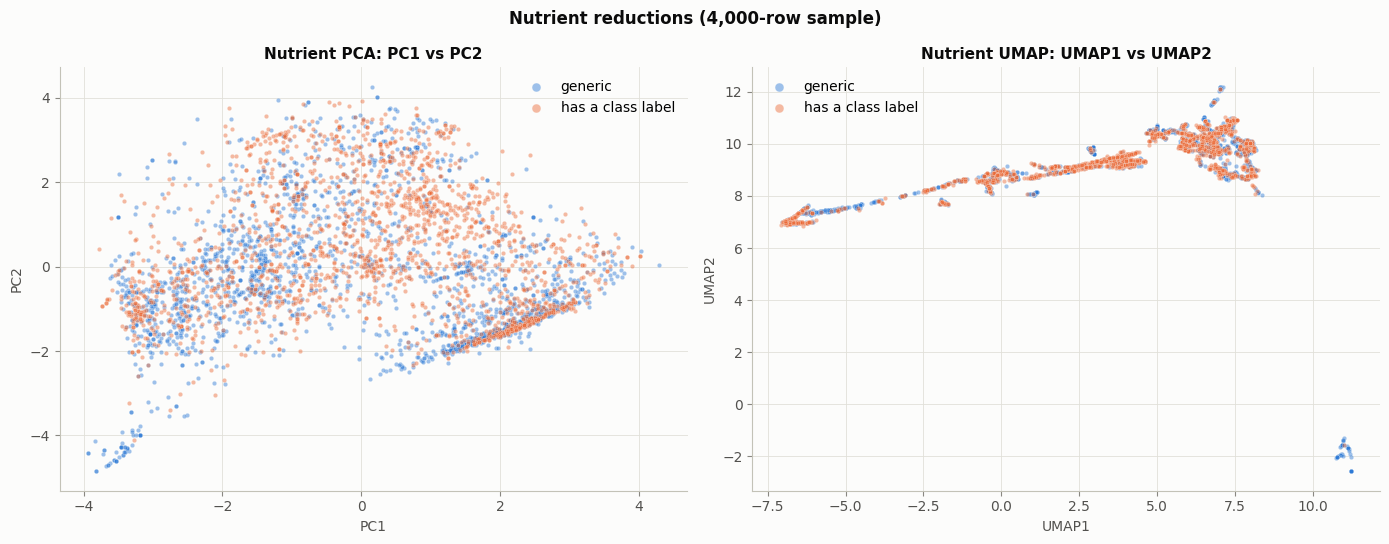

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, comps, axis_name in [(axes[0], nutrient_pcs, "PC"), (axes[1], nutrient_umap_comps, "UMAP")]:
    for mask, name, color in [(is_generic, "generic", SERIES[0]), (~is_generic, "has a class label", SERIES[1])]:
        ax.scatter(comps[sample][mask, 0], comps[sample][mask, 1], s=10, alpha=0.45,
                   color=color, edgecolors=SURFACE, linewidths=0.3, label=name)
    ax.set_xlabel(f"{axis_name}1")
    ax.set_ylabel(f"{axis_name}2")
    ax.legend(markerscale=2)
axes[0].set_title("Nutrient PCA: PC1 vs PC2")
axes[1].set_title("Nutrient UMAP: UMAP1 vs UMAP2")
fig.suptitle("Nutrient reductions (4,000-row sample)", color=INK, fontweight="bold")
fig.tight_layout()
plt.show()


## Models on UMAP features

The same six models with the same settings, on `X_umap` instead of `X`, in both set-ups used above:
- `umap_results`: the model is also the generic gate (as in the model sections).
- `umap_lr_gate_results`: a shared logistic-regression gate, refit on `X_umap` (as in the LR-gate section).

Split, labels, chain order and `predict_labels` are unchanged. XGBoost again runs in the torch-free worker.


In [59]:
umap_results = {}          # own gate, UMAP features
umap_lr_gate_results = {}  # shared LR gate, UMAP features

UMAP_MODELS = {
    "Logistic regression": lambda: LogisticRegression(class_weight="balanced", max_iter=2000),
    "KNN": lambda: KNeighborsClassifier(n_neighbors=15, weights="distance"),
    "Decision Tree": lambda: DecisionTreeClassifier(class_weight="balanced", min_samples_leaf=5,
                                                    random_state=RANDOM_STATE),
    "SVM": lambda: SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                                                    min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE),
}


def run_umap_gated_chain(name, estimator, results, gate=None):
    """Chain of `estimator` on X_umap; the gate is `estimator` too unless a fitted `gate` is given
    (then `fit seconds` covers the chain only, as in the LR-gate section)."""
    start = time.perf_counter()
    if gate is None:
        gate = clone(estimator).fit(X_umap[train_idx], Y_np[train_idx, GENERIC])
    gated_chain = ClassifierChain(clone(estimator), order=chain_order, random_state=RANDOM_STATE).fit(
        X_umap[specific_train_idx], Y_specific)
    fit_seconds = time.perf_counter() - start
    record_result(name, predict_labels(X_umap[test_idx], gate, gated_chain), fit_seconds, results)
    return gate, gated_chain


umap_generic_gate = LogisticRegression(class_weight="balanced", max_iter=2000).fit(
    X_umap[train_idx], Y_np[train_idx, GENERIC])

for gate, results in [(None, umap_results), (umap_generic_gate, umap_lr_gate_results)]:
    xgb_umap_pred, xgb_umap_seconds = get_reusable_executor(max_workers=1).submit(
        fit_predict_gated_xgb, X_umap[train_idx], Y_np[train_idx, GENERIC], X_umap[specific_train_idx], Y_specific,
        X_umap[test_idx], chain_order, gate=gate,
    ).result()
    record_result("XGBoost", xgb_umap_pred, xgb_umap_seconds, results)
    for name, make in UMAP_MODELS.items():
        run_umap_gated_chain(name, make(), results, gate=gate)


XGBoost: fit 6.7s  micro F1 0.828  macro F1 0.739  exact match 0.762
                     precision    recall  f1-score   support

   advanced_gourmet       0.68      0.62      0.65        42
 authentic_regional       0.68      0.57      0.62        69
       comfort_food       0.74      0.80      0.77       240
     game_day_snack       0.84      0.82      0.83       132
            generic       0.87      0.90      0.88      1091
holiday_celebration       0.70      0.62      0.66        34
       kid_friendly       0.87      0.89      0.88       398
    one_pot_one_pan       0.75      0.75      0.75       106
              spicy       0.42      0.44      0.43        18
  street_food_style       0.87      0.86      0.87       102
        tangy_zesty       0.73      0.67      0.70       108
         umami_rich       0.78      0.82      0.80       354
   weeknight_dinner       0.76      0.79      0.78       120

          micro avg       0.82      0.84      0.83      2814
          macr

## Comparison: PCA vs UMAP

Every model with nutrient PCA features (`X`) and with nutrient UMAP features (`X_umap`), each with its own gate and
with the shared LR gate. Same model and gate on both sides means any difference comes from the nutrient reduction.


In [60]:
pca_vs_umap = show_comparison(
    {f"{name} | PCA | own gate": r for name, r in model_results.items()}
    | {f"{name} | UMAP | own gate": r for name, r in umap_results.items()}
    | {f"{name} | PCA | LR gate": r for name, r in lr_gate_results.items()}
    | {f"{name} | UMAP | LR gate": r for name, r in umap_lr_gate_results.items()})

# macro F1 gain from UMAP over PCA, per model and gate set-up
display(pd.DataFrame({
    gate: {name: pca_vs_umap.loc[f"{name} | UMAP | {gate}", "macro F1"] - pca_vs_umap.loc[f"{name} | PCA | {gate}", "macro F1"]
           for name in model_results}
    for gate in ["own gate", "LR gate"]
}).rename_axis("macro F1: UMAP − PCA").style.format("{:+.3f}").background_gradient(cmap="RdYlGn", vmin=-0.05, vmax=0.05))


,micro F1,macro F1,samples F1,generic F1,hamming loss,exact match,no label,generic + other,fit seconds
XGBoost | PCA | own gate,0.827,0.746,0.829,0.880,0.035,0.764,0,0,6.7
XGBoost | UMAP | own gate,0.828,0.739,0.831,0.883,0.035,0.762,0,0,6.7
Random Forest | PCA | own gate,0.829,0.737,0.829,0.888,0.034,0.765,0,0,13.8
Random Forest | UMAP | own gate,0.828,0.734,0.826,0.885,0.034,0.763,0,0,12.9
KNN | UMAP | own gate,0.827,0.730,0.831,0.886,0.034,0.772,0,0,0.0
KNN | PCA | own gate,0.822,0.727,0.826,0.882,0.035,0.767,0,0,0.1
XGBoost | UMAP | LR gate,0.788,0.700,0.783,0.835,0.043,0.716,0,0,6.1
XGBoost | PCA | LR gate,0.784,0.700,0.777,0.830,0.043,0.712,0,0,6.8
KNN | UMAP | LR gate,0.782,0.693,0.777,0.835,0.043,0.717,0,0,0.0
Random Forest | UMAP | LR gate,0.785,0.693,0.777,0.835,0.042,0.716,0,0,11.2


,XGBoost | PCA | own gate,XGBoost | UMAP | own gate,Random Forest | PCA | own gate,Random Forest | UMAP | own gate,KNN | UMAP | own gate,KNN | PCA | own gate,XGBoost | UMAP | LR gate,XGBoost | PCA | LR gate,KNN | UMAP | LR gate,Random Forest | UMAP | LR gate,SVM | PCA | own gate,Random Forest | PCA | LR gate,KNN | PCA | LR gate,SVM | UMAP | own gate,SVM | PCA | LR gate,SVM | UMAP | LR gate,Logistic regression | UMAP | own gate,Logistic regression | UMAP | LR gate,Logistic regression | PCA | LR gate,Logistic regression | PCA | own gate,Decision Tree | PCA | own gate,Decision Tree | UMAP | own gate,Decision Tree | PCA | LR gate,Decision Tree | UMAP | LR gate,support
generic,0.88,0.88,0.89,0.88,0.89,0.88,0.83,0.83,0.83,0.83,0.88,0.83,0.83,0.88,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.82,0.83,0.83,1091
kid_friendly,0.87,0.88,0.88,0.87,0.87,0.87,0.85,0.85,0.84,0.84,0.87,0.85,0.84,0.86,0.85,0.84,0.82,0.82,0.82,0.82,0.78,0.79,0.79,0.79,398
umami_rich,0.80,0.80,0.79,0.79,0.80,0.77,0.74,0.74,0.72,0.73,0.76,0.72,0.71,0.77,0.72,0.72,0.69,0.69,0.69,0.69,0.65,0.67,0.65,0.68,354
comfort_food,0.76,0.77,0.75,0.77,0.76,0.74,0.74,0.73,0.73,0.74,0.74,0.72,0.72,0.72,0.71,0.70,0.66,0.66,0.67,0.67,0.66,0.63,0.65,0.63,240
game_day_snack,0.82,0.83,0.84,0.85,0.85,0.84,0.82,0.79,0.82,0.84,0.79,0.81,0.80,0.77,0.77,0.77,0.72,0.72,0.71,0.71,0.69,0.66,0.70,0.71,132
weeknight_dinner,0.81,0.78,0.79,0.78,0.78,0.76,0.78,0.81,0.79,0.78,0.71,0.78,0.77,0.72,0.70,0.71,0.71,0.71,0.68,0.68,0.61,0.63,0.63,0.63,120
tangy_zesty,0.70,0.70,0.70,0.69,0.72,0.73,0.63,0.61,0.59,0.61,0.65,0.58,0.58,0.63,0.56,0.57,0.54,0.54,0.53,0.53,0.50,0.52,0.52,0.54,108
one_pot_one_pan,0.75,0.75,0.78,0.76,0.74,0.75,0.72,0.74,0.71,0.73,0.64,0.73,0.71,0.65,0.62,0.62,0.58,0.58,0.56,0.56,0.60,0.61,0.60,0.59,106
street_food_style,0.85,0.87,0.83,0.84,0.83,0.83,0.86,0.85,0.83,0.84,0.81,0.83,0.83,0.81,0.81,0.80,0.69,0.69,0.71,0.71,0.69,0.71,0.69,0.71,102
authentic_regional,0.64,0.62,0.61,0.60,0.57,0.57,0.53,0.51,0.48,0.50,0.51,0.50,0.47,0.50,0.45,0.44,0.43,0.43,0.43,0.43,0.47,0.45,0.41,0.42,69


,own gate,LR gate
macro F1: UMAP − PCA,,
Logistic regression,+0.003,+0.003
KNN,+0.002,+0.012
Decision Tree,-0.003,-0.003
SVM,-0.011,-0.003
XGBoost,-0.007,+0.000
Random Forest,-0.003,+0.006


## Save weights: XGBoost (PCA, own gate)

`model_artifacts/recipe_classifier_xgb_pca/`, same layout as the logistic-regression model:
- `recipe_classifier.pt`: attention encoder `state_dict`, term vocabulary + frozen MiniLM term vectors, encoder config.
- `preprocessing.joblib`: nutrient train medians, nutrient scaler, PCA, feature scaler.
- `xgb_models.joblib`: XGBoost generic gate and classifier chain. Each `BalancedXGB` is unwrapped to its fitted
  `XGBClassifier`, so loading needs only sklearn + xgboost, not this notebook.
- `config.json`: label order, chain order, settings and test metrics.

XGBoost can't run next to torch (see the XGBoost section), so the gate and chain are refit, saved, reloaded and used for
prediction in the torch-free worker. The last lines check that the reloaded files reproduce the XGBoost test predictions.


In [61]:
XGB_ARTIFACT_DIR = Path("model_artifacts/recipe_classifier_xgb_pca")
XGB_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def fit_save_gated_xgb(X_fit, y_gate, X_specific, Y_specific, order, path):
    """Runs in the worker: fit the XGBoost gate + chain and save them with plain XGBClassifier links."""
    gate = BalancedXGB().fit(X_fit, y_gate)
    gated_chain = ClassifierChain(BalancedXGB(), order=order, random_state=RANDOM_STATE).fit(X_specific, Y_specific)
    gated_chain.estimators_ = [link.model_ for link in gated_chain.estimators_]
    gated_chain.set_params(estimator=XGBClassifier())
    joblib.dump({"generic_gate": gate.model_, "chain": gated_chain}, path)


def predict_saved_xgb(path, X_rows):
    """Runs in the worker: load the saved gate + chain and predict."""
    saved = joblib.load(path)
    return predict_labels(X_rows, saved["generic_gate"], saved["chain"])


get_reusable_executor(max_workers=1).submit(
    fit_save_gated_xgb, X[train_idx], Y_np[train_idx, GENERIC], X[specific_train_idx], Y_specific,
    chain_order, XGB_ARTIFACT_DIR / "xgb_models.joblib",
).result()

torch.save({"state_dict": {k: v.detach().cpu() for k, v in encoder.state_dict().items()},
            "encoder_config": encoder_config, "vocab": vocab, "term_vectors": term_vectors},
           XGB_ARTIFACT_DIR / "recipe_classifier.pt")
joblib.dump({"nutrient_cols": NUTRIENT_COLS,
             "nutrient_medians": np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[train_idx].median(),
             "nutrient_scaler": nutrient_scaler, "nutrient_pca": nutrient_pca, "feature_scaler": feature_scaler},
            XGB_ARTIFACT_DIR / "preprocessing.joblib")
xgb_saved_pred = model_results["XGBoost"]["pred"]
(XGB_ARTIFACT_DIR / "config.json").write_text(json.dumps({
    "model": "xgboost", "nutrient_reduction": "pca", "gate": "xgboost",
    "label_cols": LABEL_COLS, "dropped_labels": DROPPED_LABELS, "gate_label": "generic",
    "chain_labels": CHAIN_LABELS, "chain_order": chain_order.tolist(),
    "xgb_params": BalancedXGB().get_params(),
    "term_model": TERM_MODEL, "term_revision": TERM_REVISION, "random_state": RANDOM_STATE, "test_size": TEST_SIZE,
    "encoder_epochs": ENCODER_EPOCHS, "encoder_lr": ENCODER_LR, "nutrient_pca_variance": NUTRIENT_PCA_VARIANCE,
    "test_metrics": {"micro_f1": f1_score(Y_true, xgb_saved_pred, average="micro"),
                     "macro_f1": f1_score(Y_true, xgb_saved_pred, average="macro"),
                     "hamming_loss": hamming_loss(Y_true, xgb_saved_pred),
                     "exact_match": accuracy_score(Y_true, xgb_saved_pred)},
}, indent=2))

# reload every file and check the saved pipeline reproduces the XGBoost test predictions
saved = torch.load(XGB_ARTIFACT_DIR / "recipe_classifier.pt", weights_only=False)
reloaded = ItemAttentionEncoder(saved["term_vectors"], saved["encoder_config"]["n_labels"])
reloaded.load_state_dict(saved["state_dict"])
reloaded.eval()
prep = joblib.load(XGB_ARTIFACT_DIR / "preprocessing.joblib")
with torch.no_grad():
    emb = reloaded.embed(torch.tensor(term_ids[test_idx]), torch.tensor(type_ids[test_idx])).numpy()
nut = np.log1p(recipe_classes_df[NUTRIENT_COLS].clip(lower=0)).iloc[test_idx].fillna(prep["nutrient_medians"]).to_numpy()
pcs = prep["nutrient_pca"].transform(prep["nutrient_scaler"].transform(nut))
X_re = prep["feature_scaler"].transform(np.hstack([emb, pcs]))
xgb_reloaded_pred = get_reusable_executor(max_workers=1).submit(
    predict_saved_xgb, XGB_ARTIFACT_DIR / "xgb_models.joblib", X_re).result()
assert (xgb_reloaded_pred == xgb_saved_pred).all()
print("saved to", XGB_ARTIFACT_DIR, sorted(p.name for p in XGB_ARTIFACT_DIR.iterdir()))


saved to model_artifacts/recipe_classifier_xgb_pca ['config.json', 'preprocessing.joblib', 'recipe_classifier.pt', 'xgb_models.joblib']
